# 📊 Analisis Evolusi Topik Riset Skripsi Mahasiswa Informatika UNSOED
## Periode 2018–2025 | BERTopic (IndoSBERT-large) vs LDA (Gensim)

**Penulis:** Muhamad Galih  
**Program Studi:** Informatika, Universitas Jenderal Soedirman  
**Tanggal Analisis:** Maret 2026

---

### Tujuan Notebook
1. **Load & Eksplorasi** data skripsi dari repository UNSOED
2. **Preprocessing** teks (dual pipeline: cleaned untuk BERTopic, stemmed untuk LDA)
3. **Hyperparameter Tuning** untuk BERTopic dan LDA dengan Grid Search
4. **Training** model dengan parameter terbaik
5. **Evaluasi** menggunakan Coherence (C_v) dan Topic Diversity
6. **Dynamic Topic Analysis (DTA)** — evolusi topik per tahun
7. **Perbandingan** BERTopic vs LDA
8. **Visualisasi** dan **Export CSV** di tiap langkah

### Arsitektur Model

**BERTopic Pipeline:**
```
Teks Asli → Deep Clean PDF Artifacts → Case Folding (teks natural)
  → IndoSBERT Embedding → UMAP → HDBSCAN → c-TF-IDF + MMR
```

**LDA Pipeline:**
```
Teks Asli → Deep Clean PDF Artifacts → Case Folding → Hapus Angka/Simbol
  → Stopword Removal → Stemming (Sastrawi) → BoW → Gensim LDA
```

---
## 1. 🔧 Setup & Konfigurasi

In [16]:
# ============================================
# 1.1 Import Libraries
# ============================================
import sys
import os
import json
import time
import warnings
from pathlib import Path
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Suppress warnings untuk output yang bersih
warnings.filterwarnings('ignore')

# Matplotlib config
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

# Random seed untuk reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Tanggal Analisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.3.2
Pandas: 2.3.2
Tanggal Analisis: 2026-03-07 04:59


In [17]:
# ============================================
# 1.2 Konfigurasi Path
# ============================================

# Base directories
ANALYSIS_DIR = Path(r"c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\analysis")
FASTAPI_DIR  = Path(r"c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\fastapi")
DATA_DIR     = ANALYSIS_DIR / "data"
OUTPUT_DIR   = ANALYSIS_DIR / "output"

# Tambahkan fastapi ke sys.path agar bisa import module app
if str(FASTAPI_DIR) not in sys.path:
    sys.path.insert(0, str(FASTAPI_DIR))

# Buat sub-folder output
OUTPUT_CSV_DIR   = OUTPUT_DIR / "csv"
OUTPUT_PLOT_DIR  = OUTPUT_DIR / "plots"
OUTPUT_MODEL_DIR = OUTPUT_DIR / "models"

for d in [OUTPUT_CSV_DIR, OUTPUT_PLOT_DIR, OUTPUT_MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Direktori output siap:")
print(f"   CSV   : {OUTPUT_CSV_DIR}")
print(f"   Plots : {OUTPUT_PLOT_DIR}")
print(f"   Models: {OUTPUT_MODEL_DIR}")

✅ Direktori output siap:
   CSV   : c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\analysis\output\csv
   Plots : c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\analysis\output\plots
   Models: c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\analysis\output\models


In [ ]:
# ============================================
# 1.3 Konfigurasi Hyperparameter Grid
# ============================================

CONFIG = {
    # === Data ===
    "data_file": str(DATA_DIR / "skripsi_unsoed_scraped.json"),
    "raw_csv": str(FASTAPI_DIR / "data" / "raw" / "raw_data.csv"),
    "text_column": "combined_text",
    "year_column": "year",
    "year_range": (2018, 2026),
    
    # === Preprocessing ===
    "min_word_length": 3,
    "remove_stopwords": True,
    "use_stemming": True,
    
    # === BERTopic Embedding ===
    "embedding_model": "denaya/indoSBERT-large",
    "embedding_batch_size": 16,
    
    "bertopic_grid": {
        "umap_n_neighbors":         [5, 10, 15],
        "umap_n_components":        [5, 10],
        "umap_min_dist":            [0.0],
        "umap_metric":              ["cosine"],
        "hdbscan_min_cluster_size": [5, 8, 10, 15],
        "hdbscan_min_samples":      [1, 3],
        "hdbscan_metric":           ["euclidean"],
        "hdbscan_method":           ["eom"],
        "nr_topics":                [8, 10, 12, 15],
        "min_topic_size":           [5],
    },
    
    "bertopic_n_sample": 72,
    "bertopic_random_state_grid": RANDOM_STATE,

    # === LDA Hyperparameter Grid ===
    "lda_grid": {
        "num_topics":  [5, 8, 10, 12, 15],
        "passes":      [15, 20],
        "alpha":       ["auto", "symmetric"],
        "eta":         ["auto", "symmetric"],
        "no_below":    [5],
        "no_above":    [0.5],
    },
    
    # === Evaluation ===
    "coherence_type": "c_v",
    "top_n_words": 10,
    
    # === Global Random Seed ===
    "random_state": RANDOM_STATE,
}

# Hitung total kombinasi penuh
bertopic_combos_full = 1
for v in CONFIG["bertopic_grid"].values():
    if isinstance(v, list):
        bertopic_combos_full *= len(v)

lda_combos = 1
for v in CONFIG["lda_grid"].values():
    lda_combos *= len(v)

n_sample = CONFIG["bertopic_n_sample"]

print(f"📋 Ruang pencarian BERTopic (full) : {bertopic_combos_full} kombinasi")
print(f"📋 Diambil secara random            : {n_sample} kombinasi (seed={RANDOM_STATE})")
print(f"📋 Total kombinasi LDA              : {lda_combos}")
print(f"\n⏱️  Estimasi waktu BERTopic  : ~{n_sample * 18 // 60} menit")
print(f"⏱️  Estimasi waktu LDA       : ~{lda_combos * 20 // 60} menit")
print(f"\n📌 Parameter grid BERTopic (full search space):")
for k, v in CONFIG["bertopic_grid"].items():
    if isinstance(v, list):
        print(f"   {k:35s}: {v}")

# Simpan konfigurasi ke CSV
config_records = []
for section, params in [("bertopic_grid", CONFIG["bertopic_grid"]), ("lda_grid", CONFIG["lda_grid"])]:
    for param_name, param_values in params.items():
        if isinstance(param_values, list):
            config_records.append({
                "model": section.replace("_grid", "").upper(),
                "parameter": param_name,
                "values": str(param_values),
                "count": len(param_values),
            })

df_config = pd.DataFrame(config_records)
df_config.to_csv(OUTPUT_CSV_DIR / "step1_hyperparameter_grid_config.csv", index=False)
print(f"\n💾 Konfigurasi disimpan ke: step1_hyperparameter_grid_config.csv")
df_config

📋 Ruang pencarian BERTopic (full) : 192 kombinasi
📋 Diambil secara random            : 72 kombinasi (seed=42)
📋 Total kombinasi LDA              : 40

⏱️  Estimasi waktu BERTopic  : ~21 menit
⏱️  Estimasi waktu LDA       : ~13 menit

📌 Parameter grid BERTopic (full search space):
   umap_n_neighbors                   : [5, 10, 15]
   umap_n_components                  : [5, 10]
   umap_min_dist                      : [0.0]
   umap_metric                        : ['cosine']
   hdbscan_min_cluster_size           : [5, 8, 10, 15]
   hdbscan_min_samples                : [1, 3]
   hdbscan_metric                     : ['euclidean']
   hdbscan_method                     : ['eom']
   nr_topics                          : [8, 10, 12, 15]
   min_topic_size                     : [5]

💾 Konfigurasi disimpan ke: step1_hyperparameter_grid_config.csv


,model,parameter,values,count
0,BERTOPIC,umap_n_neighbors,"[5, 10, 15]",3
1,BERTOPIC,umap_n_components,"[5, 10]",2
2,BERTOPIC,umap_min_dist,[0.0],1
3,BERTOPIC,umap_metric,['cosine'],1
4,BERTOPIC,hdbscan_min_cluster_size,"[5, 8, 10, 15]",4
5,BERTOPIC,hdbscan_min_samples,"[1, 3]",2
6,BERTOPIC,hdbscan_metric,['euclidean'],1
7,BERTOPIC,hdbscan_method,['eom'],1
8,BERTOPIC,nr_topics,"[8, 10, 12, 15]",4
9,BERTOPIC,min_topic_size,[5],1


---
## 2. 📥 Load & Eksplorasi Data

In [19]:

# ============================================
# 2.1 Load Data
# ============================================
# Sumber data utama: skripsi_unsoed_scraped.json (hasil scraping)

json_path = Path(CONFIG["data_file"])

if json_path.exists():
    # Load dari JSON dataset hasil scraping
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    df_raw = pd.DataFrame(data_json)
    
    print(f"📋 Kolom asli di JSON: {list(df_raw.columns)}")
    
    # Mapping kolom bahasa Indonesia → bahasa Inggris
    column_mapping = {
        "Judul":              "title",
        "Penulis":            "author",
        "Tahun":              "year",
        "Abstrak":            "abstract",
        "Kata Kunci":         "keywords",
        "Kesimpulan":         "conclusion",
        "Sumber Kesimpulan":  "conclusion_source",
        "Subjects":           "subjects",
        "Divisions":          "divisions",
        "Tanggal Deposit":    "deposit_date",
        "Tanggal Modifikasi": "modified_date",
        "Tipe":               "type",
        "ID Code":            "id_code",
        "Dokumen_PDF":        "pdf_documents",
        "URL":                "url",
        "URI":                "uri",
    }
    df_raw = df_raw.rename(columns=column_mapping)
    
    # Konversi tahun ke integer
    df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce").astype("Int64")
    
    # Simpan juga sebagai raw CSV untuk penggunaan FastAPI
    raw_csv_path = Path(CONFIG["raw_csv"])
    raw_csv_path.parent.mkdir(parents=True, exist_ok=True)
    # Simpan hanya kolom yang relevan (tanpa pdf_documents dict)
    raw_cols = ["title", "author", "year", "abstract", "keywords",
                "conclusion", "conclusion_source", "divisions", "deposit_date", "url"]
    df_csv = df_raw[[c for c in raw_cols if c in df_raw.columns]]
    df_csv.to_csv(raw_csv_path, index=False, encoding="utf-8")
    
    print(f"\n✅ Data dimuat dari JSON: {json_path}")
    print(f"   → {len(df_raw)} dokumen berhasil di-load")
    print(f"   → Kolom di-mapping ke format standar")
    print(f"   💾 Disimpan juga sebagai CSV: {raw_csv_path}")
else:
    raise FileNotFoundError(f"Tidak ditemukan file data!\n  - JSON: {json_path}")

print(f"\n📊 Jumlah data  : {len(df_raw)} baris")
print(f"📊 Kolom tersedia: {list(df_raw.columns)}")

# Tampilkan hanya kolom yang relevan
display_cols = ["title", "author", "year", "keywords", "divisions"]
print(f"\n🔍 Preview data (kolom relevan):")
df_raw[[c for c in display_cols if c in df_raw.columns]].head(5)


📋 Kolom asli di JSON: ['Judul', 'Abstrak', 'Tipe', 'ID Code', 'Kata Kunci', 'Subjects', 'Divisions', 'Penulis', 'Tanggal Deposit', 'Tanggal Modifikasi', 'URI', 'Tahun', 'Dokumen_PDF', 'URL', 'Kesimpulan', 'Sumber Kesimpulan']

✅ Data dimuat dari JSON: c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\analysis\data\skripsi_unsoed_scraped.json
   → 473 dokumen berhasil di-load
   → Kolom di-mapping ke format standar
   💾 Disimpan juga sebagai CSV: c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\fastapi\data\raw\raw_data.csv

📊 Jumlah data  : 473 baris
📊 Kolom tersedia: ['title', 'abstract', 'type', 'id_code', 'keywords', 'subjects', 'divisions', 'author', 'deposit_date', 'modified_date', 'uri', 'year', 'pdf_documents', 'url', 'conclusion', 'conclusion_source']

🔍 Preview data (kolom relevan):

✅ Data dimuat dari JSON: c:\Materi Kuliah\AYO KERJAIN SKRIPSI\- Sistem\analysis\data\skripsi_unsoed_scraped.json
   → 473 dokumen berhasil di-load
   → Kolom di-mapping ke format standar
   💾 Disimpan ju

,title,author,year,keywords,divisions
0,Pengembangan Aplikasi Text Mining untuk Mengek...,Mr Haryo Bimantoro,2026,"Berita Online, Ekstraksi Informasi, Text Minin...",Fakultas Teknik > S1 Teknik Informatika
1,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,Mr. Jehian Athaya Tsani Az Zuhry,2026,"Ketahanan Pangan, LSTM, Machine Learning, Nera...",Fakultas Teknik > S1 Teknik Informatika
2,Analisis Perbandingan Performa Firebase Firest...,Mr. David Setiawan,2026,"Aplikasi Inventaris, Firebase Firestore, Flutt...",Fakultas Teknik > S1 Teknik Informatika
3,Implementasi Algoritma Dijkstra dalam Sistem I...,Mr. M. Irfan Nabiel M. Mucoffa,2026,"Website, SIG, Dijkstra, Waterfall, Laravel",Fakultas Teknik > S1 Teknik Informatika
4,Klasterisasi Data Pemohon Paspor Berdasarkan K...,Mrs. EMMA SARKILLA,2026,"Davies Bouldin Index, Klasterisasi, K-Prototyp...",Fakultas Teknik > S1 Teknik Informatika


In [20]:
# ============================================
# 2.2 Validasi Data & Statistik Awal
# ============================================

# Pastikan kolom yang dibutuhkan ada
required_cols = ["title", "abstract", "year"]
available_cols = [c for c in required_cols if c in df_raw.columns]
missing_cols = [c for c in required_cols if c not in df_raw.columns]

if missing_cols:
    print(f"❌ Kolom yang belum tersedia: {missing_cols}")
    print(f"   Kolom yang ada: {list(df_raw.columns)}")
    DATA_READY = False
else:
    DATA_READY = True
    initial_count = len(df_raw)
    
    # 1. Hapus baris tanpa abstrak
    df_raw = df_raw.dropna(subset=["abstract"])
    after_na = len(df_raw)
    
    # 2. Hapus duplikat berdasarkan abstrak
    df_raw = df_raw.drop_duplicates(subset=["abstract"])
    after_dedup = len(df_raw)
    
    # 3. Filter tahun sesuai rentang yang dikonfigurasi
    year_min, year_max = CONFIG["year_range"]
    df_raw = df_raw[df_raw["year"].between(year_min, year_max)]
    after_year = len(df_raw)
    
    df_raw = df_raw.reset_index(drop=True)
    
    print(f"✅ Data siap untuk analisis!")
    print(f"   Total awal          : {initial_count}")
    print(f"   Setelah hapus NA    : {after_na} (dihapus {initial_count - after_na})")
    print(f"   Setelah deduplikasi : {after_dedup} (dihapus {after_na - after_dedup})")
    print(f"   Setelah filter tahun ({year_min}-{year_max}): {after_year} (dihapus {after_dedup - after_year})")
    print(f"   📊 Total dokumen final: {len(df_raw)}")

print(f"\n🏷️ DATA_READY = {DATA_READY}")

✅ Data siap untuk analisis!
   Total awal          : 473
   Setelah hapus NA    : 473 (dihapus 0)
   Setelah deduplikasi : 472 (dihapus 1)
   Setelah filter tahun (2018-2026): 471 (dihapus 1)
   📊 Total dokumen final: 471

🏷️ DATA_READY = True


In [21]:
# ============================================
# 2.3 Exploratory Data Analysis
# ============================================

if DATA_READY:
    # Tambah kolom tambahan untuk analisis
    df_raw["abstract_length"] = df_raw["abstract"].astype(str).str.len()
    df_raw["word_count"] = df_raw["abstract"].astype(str).str.split().str.len()
    df_raw["title_length"] = df_raw["title"].astype(str).str.len()
    
    # --- Statistik Deskriptif ---
    stats = {
        "Metrik": [
            "Total Dokumen",
            "Rentang Tahun",
            "Rata-rata Panjang Abstrak (karakter)",
            "Rata-rata Jumlah Kata Abstrak",
            "Median Jumlah Kata Abstrak",
            "Min Jumlah Kata Abstrak",
            "Max Jumlah Kata Abstrak",
        ],
        "Nilai": [
            len(df_raw),
            f"{df_raw['year'].min()} - {df_raw['year'].max()}",
            f"{df_raw['abstract_length'].mean():.0f}",
            f"{df_raw['word_count'].mean():.1f}",
            f"{df_raw['word_count'].median():.0f}",
            f"{df_raw['word_count'].min()}",
            f"{df_raw['word_count'].max()}",
        ]
    }
    df_stats = pd.DataFrame(stats)
    df_stats.to_csv(OUTPUT_CSV_DIR / "step2_dataset_statistics.csv", index=False)
    print("💾 Statistik disimpan ke: step2_dataset_statistics.csv\n")
    display(df_stats)
    
    # --- Distribusi per Tahun ---
    df_year_dist = df_raw.groupby("year").agg(
        jumlah_skripsi=("abstract", "count"),
        rata_rata_kata=("word_count", "mean"),
    ).round(1).reset_index()
    df_year_dist.to_csv(OUTPUT_CSV_DIR / "step2_distribusi_per_tahun.csv", index=False)
    print("\n💾 Distribusi per tahun disimpan ke: step2_distribusi_per_tahun.csv")
    display(df_year_dist)
else:
    print("⏭️ Langkah ini dilewati — data belum tersedia.")

💾 Statistik disimpan ke: step2_dataset_statistics.csv



,Metrik,Nilai
0,Total Dokumen,471
1,Rentang Tahun,2018 - 2026
2,Rata-rata Panjang Abstrak (karakter),1288
3,Rata-rata Jumlah Kata Abstrak,165.2
4,Median Jumlah Kata Abstrak,161
5,Min Jumlah Kata Abstrak,54
6,Max Jumlah Kata Abstrak,302



💾 Distribusi per tahun disimpan ke: step2_distribusi_per_tahun.csv


,year,jumlah_skripsi,rata_rata_kata
0,2018,47,143.5
1,2019,45,142.0
2,2020,25,142.7
3,2021,51,161.3
4,2022,52,165.6
5,2023,59,166.4
6,2024,87,176.1
7,2025,85,176.8
8,2026,20,205.0


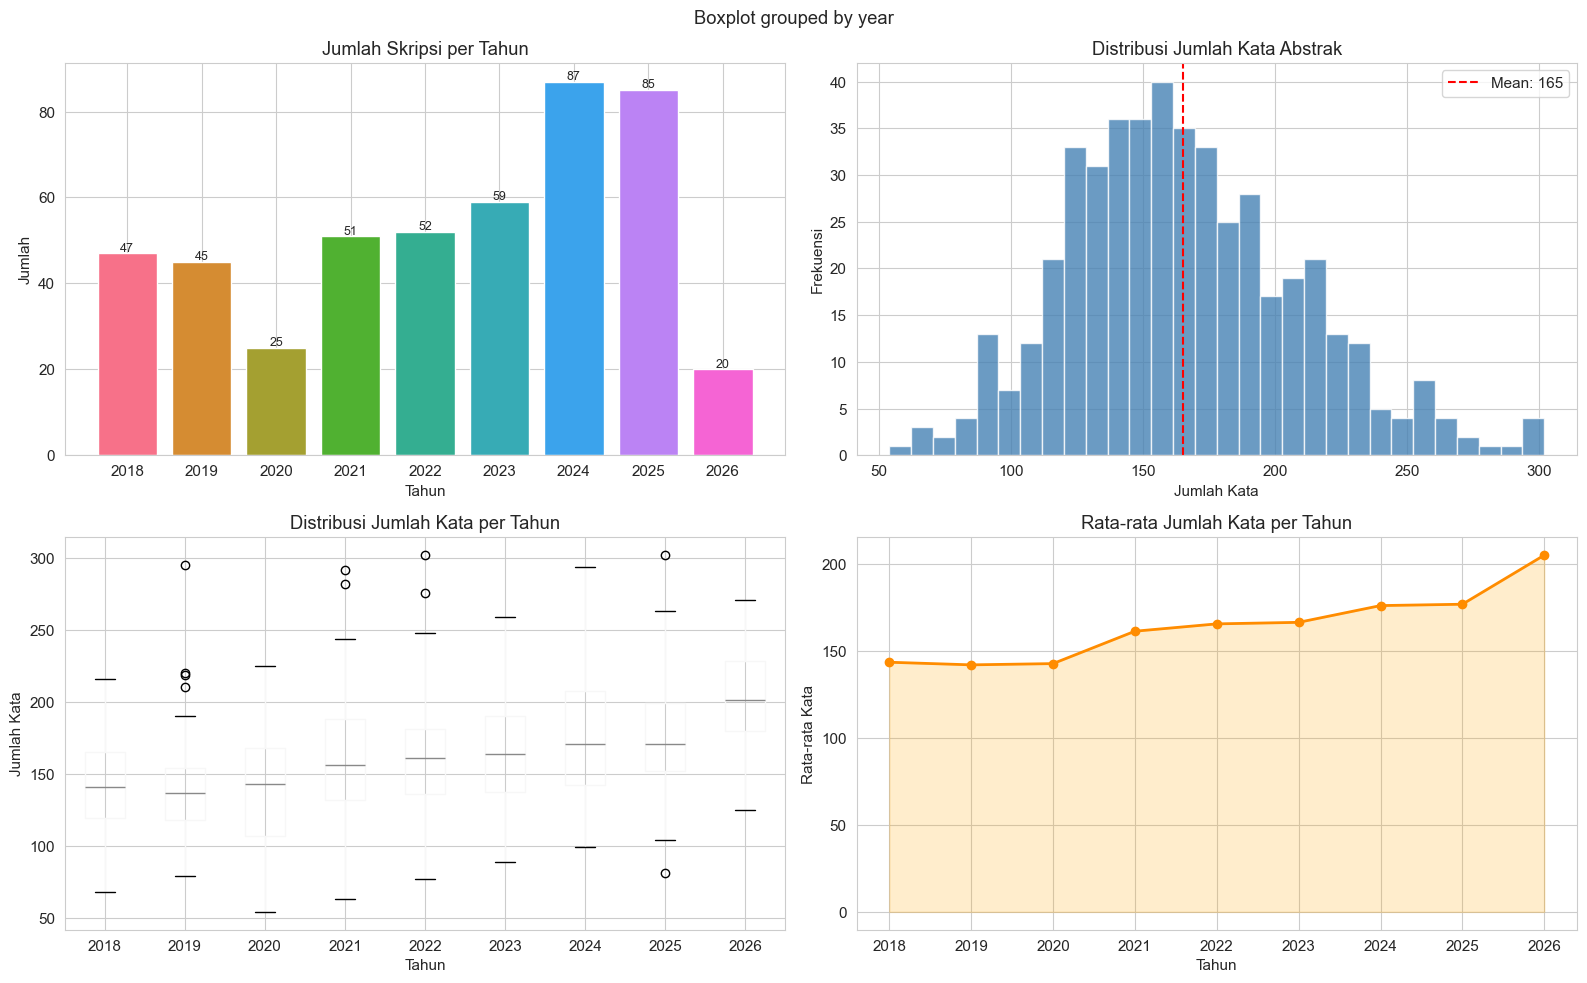

💾 Plot disimpan ke: step2_eda_overview.png


In [22]:
# ============================================
# 2.4 Visualisasi EDA
# ============================================

if DATA_READY:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Exploratory Data Analysis — Skripsi Informatika UNSOED", fontsize=14, fontweight="bold")
    
    # 1. Bar chart: Jumlah skripsi per tahun
    ax1 = axes[0, 0]
    year_counts = df_raw["year"].value_counts().sort_index()
    bars = ax1.bar(year_counts.index.astype(str), year_counts.values, color=sns.color_palette("husl", len(year_counts)))
    ax1.set_title("Jumlah Skripsi per Tahun")
    ax1.set_xlabel("Tahun")
    ax1.set_ylabel("Jumlah")
    for bar, val in zip(bars, year_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontsize=9)
    
    # 2. Histogram: Distribusi jumlah kata
    ax2 = axes[0, 1]
    ax2.hist(df_raw["word_count"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax2.axvline(df_raw["word_count"].mean(), color="red", linestyle="--", label=f"Mean: {df_raw['word_count'].mean():.0f}")
    ax2.set_title("Distribusi Jumlah Kata Abstrak")
    ax2.set_xlabel("Jumlah Kata")
    ax2.set_ylabel("Frekuensi")
    ax2.legend()
    
    # 3. Boxplot: Jumlah kata per tahun
    ax3 = axes[1, 0]
    df_raw.boxplot(column="word_count", by="year", ax=ax3)
    ax3.set_title("Distribusi Jumlah Kata per Tahun")
    ax3.set_xlabel("Tahun")
    ax3.set_ylabel("Jumlah Kata")
    plt.sca(ax3)
    plt.title("Distribusi Jumlah Kata per Tahun")
    
    # 4. Line chart: Tren rata-rata kata per tahun
    ax4 = axes[1, 1]
    avg_words = df_raw.groupby("year")["word_count"].mean()
    ax4.plot(avg_words.index, avg_words.values, marker='o', linewidth=2, color="darkorange")
    ax4.fill_between(avg_words.index, avg_words.values, alpha=0.2, color="orange")
    ax4.set_title("Rata-rata Jumlah Kata per Tahun")
    ax4.set_xlabel("Tahun")
    ax4.set_ylabel("Rata-rata Kata")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step2_eda_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step2_eda_overview.png")
else:
    print("⏭️ Langkah ini dilewati — data belum tersedia.")

---
## 3. 🔤 Text Preprocessing

In [23]:

# ============================================
# 3.1 Dual Preprocessing Pipeline
# ============================================
# 
# ┌─────────────────────────────────────────────────────────────────────┐
# │ Penggabungan Teks (combined_text):                                 │
# │   - Jika Kesimpulan TIDAK kosong: Judul + Abstrak + Kesimpulan     │
# │   - Jika Kesimpulan KOSONG     : Judul + Abstrak saja              │
# │                                                                    │
# │ Pipeline BERTopic (cleaned_text):                                  │
# │   combined_text                                                    │
# │     → Deep clean PDF artifacts + metadata scraping artifacts       │
# │     → Case folding (lowercase)                                     │
# │     → Normalisasi whitespace                                       │
# │     → IndoSBERT embedding (teks NATURAL, dengan stopword & angka)  │
# │                                                                    │
# │ Pipeline LDA (processed_text):                                     │
# │   combined_text                                                    │
# │     → Deep clean PDF artifacts + metadata scraping artifacts       │
# │     → Case folding + hapus angka + hapus simbol                    │
# │     → Stopword removal                                             │
# │     → Stemming (Sastrawi)                                          │
# │     → Gensim LDA                                                   │
# └─────────────────────────────────────────────────────────────────────┘

import re
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords as nltk_stopwords

# -------------------------------------------
# A) DEEP CLEANING untuk data hasil PDF extraction + scraping artifacts
# -------------------------------------------
def deep_clean_pdf_text(text: str) -> str:
    """
    Membersihkan teks yang diekstrak dari PDF skripsi + artifact metadata scraping.
    
    Menghapus:
    - Metadata scraping EPrints: "Item Type:Thesis", "Nomor Inventaris:H26079",
      "Uncontrolled Keywords:...", "Subjects:...", "Divisions:...",
      "Depositing User:...", "Date Deposited:...", "Last Modified:...", "URI:..."
    - Nomor halaman (65, 66, ...)
    - Header BAB (BAB V, BAB IV, dll)
    - Judul section (PENUTUP, KESIMPULAN DAN SARAN, dll)
    - Numbering sub-bab (5.1, 5.2, 1., 2., a., b., dll)
    - Referensi gambar/tabel/halaman
    - URL, email, DOI
    """
    if not text or not isinstance(text, str):
        return ""
    
    # 1. Normalisasi newlines & whitespace dasar
    text = text.replace("\\n", "\n")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    
    # 2. ─── KRITIS: Hapus artifact metadata scraping EPrints ───────────────
    # Pattern: "Item Type:Thesis\n\n\n(Skripsi)Nomor Inventaris:H26079..."
    # Ini muncul di akhir field Abstrak karena scraper mengambil blok teks termasuk metadata
    
    # Hapus blok mulai dari "Item Type:" sampai akhir atau sampai teks substantif berikutnya
    text = re.sub(r"Item\s+Type\s*:.*", "", text, flags=re.DOTALL | re.IGNORECASE)
    
    # Hapus sisa metadata yang mungkin masih ada secara individual
    metadata_patterns = [
        r"Nomor\s+Inventaris\s*:\s*\S+",
        r"Uncontrolled\s+Keywords\s*:.*?(?=\n[A-Z]|\Z)",
        r"Subjects\s*:[A-Z\s>]+[A-Z0-9\s]+",
        r"Divisions\s*:.*?(?=\n[A-Z]|\Z)",
        r"Depositing\s+User\s*:.*?(?=\n|\Z)",
        r"Date\s+Deposited\s*:.*?(?=\n|\Z)",
        r"Last\s+Modified\s*:.*?(?=\n|\Z)",
        r"URI\s*:\s*http\S*",
        r"[A-Z][a-z]+\s+[A-Z][a-z]+\s*:\s*[A-Z0-9\s]+(?=\n|$)",  # pola "Key:Value" metadata
    ]
    for pattern in metadata_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    
    # 3. Hapus nomor halaman standalone (angka 1-4 digit di awal/akhir baris)
    text = re.sub(r"^\s*\d{1,4}\s*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"(?:^|\n)\s*\d{1,4}\s*(?:\n|$)", "\n", text)
    
    # 4. Hapus header BAB (BAB I, BAB II, ..., BAB V, BAB VI, dll)
    text = re.sub(r"\bBAB\s+[IVXLCDM]+\b", "", text, flags=re.IGNORECASE)
    
    # 5. Hapus judul section yang umum di skripsi
    section_headers = [
        r"KESIMPULAN\s+DAN\s+SARAN",
        r"KESIMPULAN\s*&\s*SARAN",
        r"PENUTUP",
        r"KESIMPULAN",
        r"SARAN",
        r"DAFTAR\s+PUSTAKA",
        r"DAFTAR\s+REFERENSI",
        r"ABSTRAK",
        r"ABSTRACT",
        r"KATA\s+PENGANTAR",
        r"DAFTAR\s+ISI",
        r"DAFTAR\s+GAMBAR",
        r"DAFTAR\s+TABEL",
        r"DAFTAR\s+LAMPIRAN",
        r"PENDAHULUAN",
        r"TINJAUAN\s+PUSTAKA",
        r"LANDASAN\s+TEORI",
        r"METODOLOGI\s+PENELITIAN",
        r"METODE\s+PENELITIAN",
        r"HASIL\s+DAN\s+PEMBAHASAN",
    ]
    for header in section_headers:
        text = re.sub(rf"(?:^|\n)\s*{header}\s*(?:\n|$)", "\n", text, flags=re.IGNORECASE)
    
    # 6. Hapus numbering sub-bab: "5.1.", "5.1", "5.2.", "1.", "2.", "a.", "b."
    text = re.sub(r"(?:^|\n)\s*\d+\.\d+\.?\s*", "\n", text)
    text = re.sub(r"(?:^|\n)\s*\d+\.\s+", "\n", text)
    text = re.sub(r"(?:^|\n)\s*[a-z]\.\s+", "\n", text)
    
    # 7. Hapus referensi gambar/tabel/halaman
    text = re.sub(r"(?:Gambar|Tabel|Lampiran)\s+\d+[\.\-]?\s*\d*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"(?:halaman|hal\.?|hlm\.?)\s+\d+[\-–]?\d*", "", text, flags=re.IGNORECASE)
    
    # 8. Hapus pattern "PDF (BabV)" atau source annotations
    text = re.sub(r"PDF\s*\([^)]*\)", "", text, flags=re.IGNORECASE)
    
    # 9. Hapus URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    
    # 10. Hapus email
    text = re.sub(r"\S+@\S+\.\S+", "", text)
    
    # 11. Hapus DOI
    text = re.sub(r"(?:doi|DOI)\s*:\s*\S+", "", text)
    text = re.sub(r"https?://doi\.org/\S+", "", text)
    
    # 12. Normalisasi karakter khusus (smart quotes → standard)
    text = text.replace("\u2013", "-").replace("\u2014", "-")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u2018", "'").replace("\u2019", "'")
    
    # 13. Hapus multiple newlines → single space
    text = re.sub(r"\n+", " ", text)
    
    # 14. Hapus extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


# -------------------------------------------
# B) TEXT PREPROCESSING FUNCTIONS
# -------------------------------------------
def clean_text_for_embedding(text: str) -> str:
    """
    MINIMAL cleaning untuk BERTopic / IndoSBERT embedding.
    Prinsip: Biarkan teks se-NATURAL mungkin agar IndoSBERT
    bisa menghasilkan embedding berkualitas tinggi.
    """
    text = deep_clean_pdf_text(text)
    text = text.lower()
    # Hapus karakter non-printable / control characters yang tersisa
    text = re.sub(r"[^\x20-\x7E\u00C0-\u024F\u1E00-\u1EFF\w\s.,;:!?\"'()\-/]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_lda(text: str) -> str:
    """
    Full preprocessing untuk LDA (Gensim).
    LDA berbasis Bag-of-Words sehingga butuh cleaning lebih agresif.
    """
    text = deep_clean_pdf_text(text)
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = text.split()
    tokens = [t for t in tokens if len(t) >= CONFIG["min_word_length"]]
    
    if CONFIG["remove_stopwords"]:
        tokens = [t for t in tokens if t not in stopword_set]
    
    if CONFIG["use_stemming"] and stemmer is not None:
        tokens = [stemmer.stem(t) for t in tokens]
    
    tokens = [t for t in tokens if len(t) >= CONFIG["min_word_length"]]
    
    return " ".join(tokens)


# -------------------------------------------
# C) INISIALISASI RESOURCES
# -------------------------------------------
if DATA_READY:
    # Stopwords: NLTK Indonesian + custom academic terms
    stopword_set = set(nltk_stopwords.words("indonesian"))
    academic_stopwords = {
        "penelitian", "menggunakan", "digunakan", "berdasarkan",
        "hasil", "menunjukkan", "bahwa", "dapat", "dilakukan",
        "metode", "sistem", "data", "proses", "dalam",
        "dengan", "untuk", "pada", "dari", "yang",
        "ini", "tersebut", "adalah", "merupakan", "yaitu",
        "juga", "serta", "atau", "dan", "di",
        "ke", "se", "ber", "ter", "per",
        "skripsi", "tugas", "akhir", "universitas", "mahasiswa",
        "informatika", "jurusan", "program", "studi",
        "satu", "dua", "tiga", "empat", "lima",
        "oleh", "akan", "telah", "tidak", "lebih",
        "secara", "melalui", "antara", "setiap", "hingga",
        "sebagai", "seperti", "agar", "bagi", "tentang",
    }
    stopword_set.update(academic_stopwords)
    stopword_list = list(stopword_set)
    
    print(f"✅ Stopwords loaded: {len(stopword_set)} kata")
    
    # Stemmer: Sastrawi (hanya untuk LDA)
    stemmer = None
    try:
        from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
        factory = StemmerFactory()
        if hasattr(factory, 'createStemmer'):
            stemmer = factory.createStemmer()
        elif hasattr(factory, 'create_stemmer'):
            stemmer = factory.create_stemmer()
        else:
            methods = [m for m in dir(factory) if 'stem' in m.lower()]
            if methods:
                stemmer = getattr(factory, methods[0])()
        
        if stemmer is not None:
            test = stemmer.stem("berlari")
            print(f"✅ Sastrawi stemmer loaded (test: 'berlari' → '{test}')")
        else:
            print("⚠️ Sastrawi: tidak dapat membuat stemmer instance")
    except Exception as e:
        print(f"⚠️ Sastrawi error: {e}")
    
    # -------------------------------------------
    # D) BUAT KOLOM combined_text (Judul + Abstrak + Kesimpulan)
    # -------------------------------------------
    print(f"\n⏳ Membuat kolom combined_text...")
    
    df_processed = df_raw.copy()
    
    def combine_text(row):
        """Gabungkan Judul + Abstrak + Kesimpulan (jika ada dan valid)."""
        title      = str(row.get("title", "")).strip()
        abstract   = str(row.get("abstract", "")).strip()
        conclusion = str(row.get("conclusion", "")).strip()
        
        # Bersihkan dulu sebelum digabung agar artifact tidak masuk combined_text
        title      = deep_clean_pdf_text(title)
        abstract   = deep_clean_pdf_text(abstract)
        conclusion = deep_clean_pdf_text(conclusion)
        
        conclusion_valid = (
            conclusion
            and conclusion.lower() not in ("", "nan", "none", "tidak tersedia")
            and len(conclusion) >= 100
        )
        
        if conclusion_valid:
            return f"{title}. {abstract}. {conclusion}"
        else:
            return f"{title}. {abstract}"
    
    df_processed["combined_text"] = df_processed.apply(combine_text, axis=1)
    
    has_conclusion = df_processed["conclusion"].fillna("").str.strip().apply(
        lambda x: (x != ""
                   and x.lower() not in ("nan", "none", "tidak tersedia")
                   and len(deep_clean_pdf_text(x)) >= 100)
    )
    n_with_conclusion    = has_conclusion.sum()
    n_without_conclusion = (~has_conclusion).sum()
    
    print(f"\n📊 Statistik combined_text:")
    print(f"   Dengan Kesimpulan : {n_with_conclusion} dokumen")
    print(f"   Tanpa Kesimpulan  : {n_without_conclusion} dokumen")
    print(f"   Total             : {len(df_processed)} dokumen")
    
    # -------------------------------------------
    # E) JALANKAN PREPROCESSING
    # -------------------------------------------
    print(f"\n⏳ Menjalankan dual preprocessing pipeline...")
    start_time = time.time()
    
    df_processed["cleaned_text"]   = df_processed["combined_text"].apply(clean_text_for_embedding)
    df_processed["processed_text"] = df_processed["combined_text"].apply(clean_text_for_lda)
    
    # Hapus dokumen yang kosong setelah preprocessing
    before_count = len(df_processed)
    mask = (
        (df_processed["cleaned_text"].str.strip().str.len() > 0)
        & (df_processed["processed_text"].str.strip().str.len() > 0)
    )
    df_processed = df_processed[mask].reset_index(drop=True)
    after_count = len(df_processed)
    
    if before_count != after_count:
        print(f"\n⚠️ {before_count - after_count} dokumen dihapus (teks kosong setelah cleaning)")
    
    duration = time.time() - start_time
    print(f"\n✅ Preprocessing selesai dalam {duration:.1f} detik")
    print(f"   Dokumen final: {len(df_processed)}")
    
    # Tambah kolom word count
    df_processed["cleaned_word_count"]   = df_processed["cleaned_text"].str.split().str.len()
    df_processed["processed_word_count"] = df_processed["processed_text"].str.split().str.len()
    
else:
    print("⏭️ Langkah ini dilewati — data belum tersedia.")


✅ Stopwords loaded: 774 kata
✅ Sastrawi stemmer loaded (test: 'berlari' → 'lari')

⏳ Membuat kolom combined_text...
✅ Sastrawi stemmer loaded (test: 'berlari' → 'lari')

⏳ Membuat kolom combined_text...

📊 Statistik combined_text:
   Dengan Kesimpulan : 324 dokumen
   Tanpa Kesimpulan  : 147 dokumen
   Total             : 471 dokumen

⏳ Menjalankan dual preprocessing pipeline...

📊 Statistik combined_text:
   Dengan Kesimpulan : 324 dokumen
   Tanpa Kesimpulan  : 147 dokumen
   Total             : 471 dokumen

⏳ Menjalankan dual preprocessing pipeline...

✅ Preprocessing selesai dalam 797.5 detik
   Dokumen final: 471

✅ Preprocessing selesai dalam 797.5 detik
   Dokumen final: 471


In [24]:

# ============================================
# 3.2 Statistik Preprocessing & Tabel Before/After
# ============================================

if DATA_READY:
    # -- Tabel 1: Ringkasan Statistik Pipeline --
    prep_stats = {
        "Pipeline": ["Original (Abstrak)", "Cleaned (BERTopic)", "Processed (LDA)"],
        "Jumlah Dokumen": [
            len(df_raw),
            len(df_processed),
            len(df_processed),
        ],
        "Rata-rata Kata": [
            f"{df_raw['word_count'].mean():.1f}",
            f"{df_processed['cleaned_word_count'].mean():.1f}",
            f"{df_processed['processed_word_count'].mean():.1f}",
        ],
        "Min Kata": [
            int(df_raw["word_count"].min()),
            int(df_processed["cleaned_word_count"].min()),
            int(df_processed["processed_word_count"].min()),
        ],
        "Max Kata": [
            int(df_raw["word_count"].max()),
            int(df_processed["cleaned_word_count"].max()),
            int(df_processed["processed_word_count"].max()),
        ],
        "Keterangan": [
            "Teks abstrak asli dari JSON",
            "Deep clean PDF + case folding (teks natural untuk IndoSBERT)",
            "Deep clean PDF + hapus angka/simbol + stopword removal + stemming (untuk LDA)",
        ],
    }
    df_prep_stats = pd.DataFrame(prep_stats)
    df_prep_stats.to_csv(OUTPUT_CSV_DIR / "step3_preprocessing_statistics.csv", index=False)
    print("STATISTIK PREPROCESSING")
    print("="*60)
    print("Disimpan ke: step3_preprocessing_statistics.csv\n")
    display(df_prep_stats)

    # -- Tabel 2: Before vs After (per dokumen, 3 sampel) --
    print("\n" + "="*60)
    print("CONTOH BEFORE -> AFTER PREPROCESSING (3 Sampel)")
    print("="*60)

    n_samples = min(3, len(df_processed))
    before_after_records = []
    for i in range(n_samples):
        row = df_processed.iloc[i]
        mask_title = df_raw["title"] == row["title"]
        if mask_title.any():
            original_abstract = str(df_raw.loc[mask_title, "abstract"].values[0])
            kata_before = df_raw.loc[mask_title, "word_count"].values[0]
        else:
            original_abstract = str(row.get("abstract", ""))
            kata_before = "-"
        before_after_records.append({
            "No": i + 1,
            "Judul (singkat)": row["title"][:60] + "...",
            "BEFORE - Abstrak Asli (200 char)": original_abstract[:200].replace("\n", " ") + "...",
            "AFTER - Cleaned / BERTopic (200 char)": row["cleaned_text"][:200] + "...",
            "AFTER - Processed / LDA (200 char)": row["processed_text"][:200] + "...",
            "Kata (Before)": kata_before,
            "Kata (Cleaned)": row["cleaned_word_count"],
            "Kata (Processed)": row["processed_word_count"],
        })

    df_before_after = pd.DataFrame(before_after_records)

    pd.set_option("display.max_colwidth", 220)
    for _, sample in df_before_after.iterrows():
        print(f"\n-- Dokumen #{sample['No']}: {sample['Judul (singkat)']}")
        print(f"   [BEFORE] abstrak asli  [{sample['Kata (Before)']} kata]:")
        print(f"      {sample['BEFORE - Abstrak Asli (200 char)']}")
        print(f"   [AFTER]  cleaned (BERTopic) [{sample['Kata (Cleaned)']} kata]:")
        print(f"      {sample['AFTER - Cleaned / BERTopic (200 char)']}")
        print(f"   [AFTER]  processed (LDA)    [{sample['Kata (Processed)']} kata]:")
        print(f"      {sample['AFTER - Processed / LDA (200 char)']}")
    pd.reset_option("display.max_colwidth")

    # -- Simpan CSV step3 -- hanya kolom yang diperlukan --
    save_cols = [
        "title", "author", "year", "keywords", "divisions",
        "combined_text", "cleaned_text", "processed_text",
        "cleaned_word_count", "processed_word_count",
        "conclusion_source",
    ]
    save_cols_existing = [c for c in save_cols if c in df_processed.columns]
    df_processed[save_cols_existing].to_csv(
        OUTPUT_CSV_DIR / "step3_processed_data.csv", index=False
    )
    print(f"\nData processed disimpan ke: step3_processed_data.csv")
    print(f"Kolom: {save_cols_existing}")
    print(f"Dokumen: {len(df_processed)}")
else:
    print("Langkah ini dilewati.")


STATISTIK PREPROCESSING
Disimpan ke: step3_preprocessing_statistics.csv



,Pipeline,Jumlah Dokumen,Rata-rata Kata,Min Kata,Max Kata,Keterangan
0,Original (Abstrak),471,165.2,54,302,Teks abstrak asli dari JSON
1,Cleaned (BERTopic),471,284.3,71,950,Deep clean PDF + case folding (teks natural un...
2,Processed (LDA),471,156.6,39,605,Deep clean PDF + hapus angka/simbol + stopword...



CONTOH BEFORE -> AFTER PREPROCESSING (3 Sampel)

-- Dokumen #1: Pengembangan Aplikasi Text Mining untuk Mengekstraksi Inform...
   [BEFORE] abstrak asli  [174 kata]:
      Kebiasaan masyarakat Indonesia yang cenderung hanya membaca judul berita tanpa memahami isi keseluruhan artikel dapat memicul kekeliruan informasi dan penyebaran berita palsu (hoax). Untuk mengatasi p...
   [AFTER]  cleaned (BERTopic) [254 kata]:
      pengembangan aplikasi text mining untuk mengekstraksi informasi poin penting menggunakan algoritma support vector machine. kebiasaan masyarakat indonesia yang cenderung hanya membaca judul berita tanp...
   [AFTER]  processed (LDA)    [149 kata]:
      kembang aplikasi text mining ekstraksi informasi poin algoritma support vector machine biasa masyarakat indonesia cenderung baca judul berita paham isi artikel memicul keliru informasi sebar berita pa...

-- Dokumen #2: Implementasi LSTM Untuk Prediksi Konsumsi Kalori Harian Berd...
   [BEFORE] abstrak asli  [175 kata]:

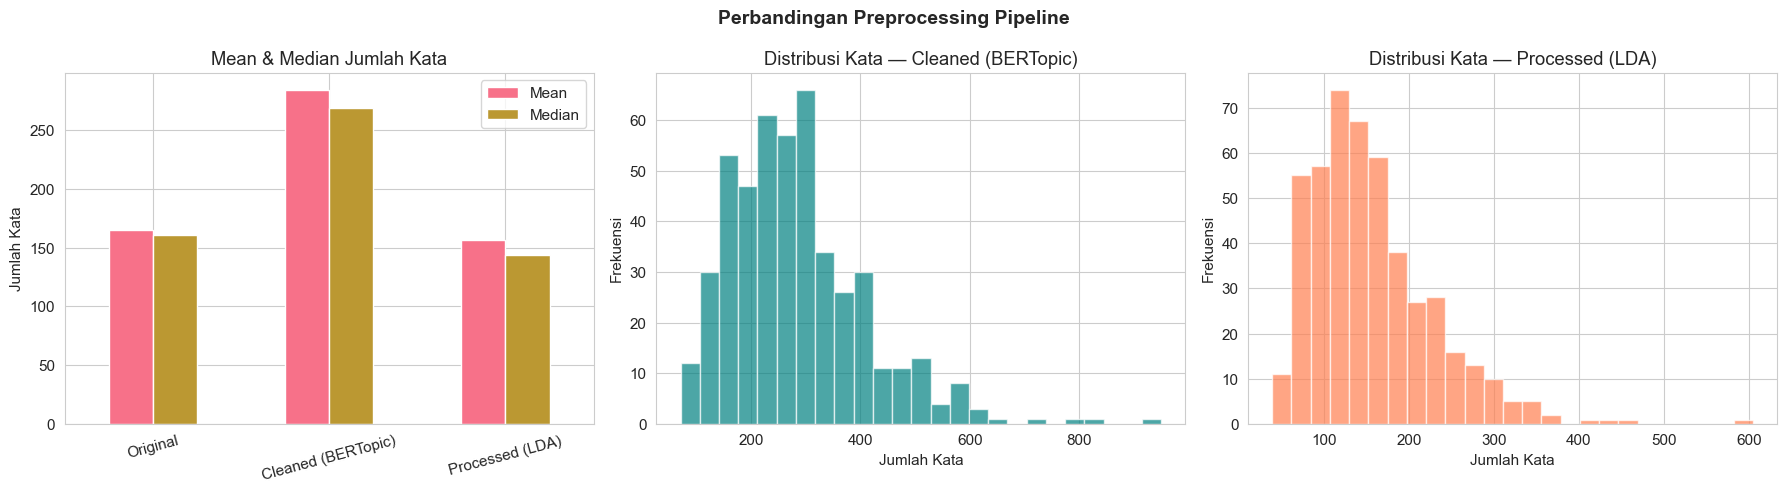

💾 Plot disimpan ke: step3_preprocessing_comparison.png


In [25]:
# ============================================
# 3.3 Visualisasi Preprocessing
# ============================================

if DATA_READY:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Perbandingan Preprocessing Pipeline", fontsize=14, fontweight="bold")
    
    # 1. Perbandingan jumlah kata
    ax1 = axes[0]
    comparison_data = pd.DataFrame({
        "Original": df_raw["word_count"].describe(),
        "Cleaned (BERTopic)": df_processed["cleaned_word_count"].describe(),
        "Processed (LDA)": df_processed["processed_word_count"].describe(),
    }).T
    comparison_data[["mean", "50%"]].plot(kind="bar", ax=ax1)
    ax1.set_title("Mean & Median Jumlah Kata")
    ax1.set_ylabel("Jumlah Kata")
    ax1.tick_params(axis='x', rotation=15)
    ax1.legend(["Mean", "Median"])
    
    # 2. Distribusi cleaned
    ax2 = axes[1]
    ax2.hist(df_processed["cleaned_word_count"], bins=25, alpha=0.7, color="teal", edgecolor="white")
    ax2.set_title("Distribusi Kata — Cleaned (BERTopic)")
    ax2.set_xlabel("Jumlah Kata")
    ax2.set_ylabel("Frekuensi")
    
    # 3. Distribusi processed (stemmed)
    ax3 = axes[2]
    ax3.hist(df_processed["processed_word_count"], bins=25, alpha=0.7, color="coral", edgecolor="white")
    ax3.set_title("Distribusi Kata — Processed (LDA)")
    ax3.set_xlabel("Jumlah Kata")
    ax3.set_ylabel("Frekuensi")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step3_preprocessing_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step3_preprocessing_comparison.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 4. 🧠 BERTopic — Compute Embeddings

In [26]:

# ============================================
# 4.1 Compute Sentence Embeddings (IndoSBERT-large)
# ============================================
# Embeddings dihitung SEKALI dan di-reuse untuk semua kombinasi hyperparameter

if DATA_READY:
    from sentence_transformers import SentenceTransformer
    
    embedding_model_name = CONFIG["embedding_model"]
    print(f"⏳ Loading model: {embedding_model_name}")
    print(f"   Arsitektur : indobert-large-p1 (hidden 1024)")
    print(f"                → Pooling (1024) → Dense(1024→256, Tanh)")
    print(f"   Output dim : 256 (setelah Dense layer)")
    
    st_model = SentenceTransformer(embedding_model_name)
    
    documents_cleaned = df_processed["cleaned_text"].tolist()
    documents_stemmed = df_processed["processed_text"].tolist()
    
    print(f"\n⏳ Computing embeddings untuk {len(documents_cleaned)} dokumen...")
    start_time = time.time()
     
    embeddings = st_model.encode(
        documents_cleaned,
        show_progress_bar=True,
        batch_size=CONFIG["embedding_batch_size"],
    )
    
    embed_duration = time.time() - start_time
    print(f"\n✅ Embeddings selesai dalam {embed_duration:.1f} detik")
    print(f"   Shape: {embeddings.shape}  (dokumen × dimensi)")
    assert embeddings.shape[1] == 256, f"⚠️ Dimensi tidak sesuai: {embeddings.shape[1]} (expected 256)"
    
    # Simpan embeddings untuk reuse
    np.save(OUTPUT_MODEL_DIR / "embeddings_indosbert_large.npy", embeddings)
    print(f"💾 Embeddings disimpan ke: embeddings_indosbert_large.npy")
    
    # Simpan info
    embed_info = pd.DataFrame([{
        "model": embedding_model_name,
        "num_documents": embeddings.shape[0],
        "embedding_dim": embeddings.shape[1],
        "duration_seconds": round(embed_duration, 2),
        "batch_size": CONFIG["embedding_batch_size"],
    }])
    embed_info.to_csv(OUTPUT_CSV_DIR / "step4_embedding_info.csv", index=False)
    display(embed_info)
else:
    print("⏭️ Langkah ini dilewati.")


⏳ Loading model: denaya/indoSBERT-large
   Arsitektur : indobert-large-p1 (hidden 1024)
                → Pooling (1024) → Dense(1024→256, Tanh)
   Output dim : 256 (setelah Dense layer)

⏳ Computing embeddings untuk 471 dokumen...

⏳ Computing embeddings untuk 471 dokumen...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]


✅ Embeddings selesai dalam 833.2 detik
   Shape: (471, 256)  (dokumen × dimensi)
💾 Embeddings disimpan ke: embeddings_indosbert_large.npy


,model,num_documents,embedding_dim,duration_seconds,batch_size
0,denaya/indoSBERT-large,471,256,833.2,16


---
## 5. 🔬 Hyperparameter Tuning — BERTopic

In [29]:

# ============================================
# 5.1 BERTopic Grid Search
# ============================================

from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

if DATA_READY:
    import random

    # -------------------------------------------
    # A) Siapkan tokenized docs untuk Coherence evaluation
    # -------------------------------------------
    # BERTopic menggunakan cleaned_text (teks natural, BUKAN stemmed)
    # Untuk CoherenceModel, kita tokenize cleaned_text (split by space)
    tokenized_docs_cleaned = [doc.split() for doc in documents_cleaned]

    # Build Gensim Dictionary dari cleaned tokens (dipakai di Step 8.1)
    gensim_dict_cleaned = Dictionary(tokenized_docs_cleaned)
    gensim_dict_cleaned.filter_extremes(no_below=3, no_above=0.95)
    print(f"✅ Gensim Dictionary (cleaned): {len(gensim_dict_cleaned)} tokens unik")

    # -------------------------------------------
    # B) Bangun daftar kombinasi hyperparameter
    # -------------------------------------------
    bg = CONFIG["bertopic_grid"]
    bt_param_keys = list(bg.keys())
    bt_param_values = list(bg.values())
    all_combinations = list(product(*bt_param_values))

    # Random sample (reproducible dengan RANDOM_STATE)
    rng = random.Random(CONFIG["bertopic_random_state_grid"])
    n_sample_bt = CONFIG["bertopic_n_sample"]
    sampled_combinations = rng.sample(all_combinations, min(n_sample_bt, len(all_combinations)))

    print(f"\n🔬 BERTopic Grid Search")
    print(f"   Total ruang pencarian : {len(all_combinations)} kombinasi")
    print(f"   Sampel yang dijalankan: {len(sampled_combinations)} kombinasi (seed={RANDOM_STATE})")
    print(f"   Embedding shape       : {embeddings.shape}")
    print("="*70)

    bt_results = []
    csv_path_bt = OUTPUT_CSV_DIR / "step5_bertopic_tuning_results.csv"

    for idx, combo in enumerate(sampled_combinations):
        params = dict(zip(bt_param_keys, combo))
        run_id = f"BT_{idx+1:03d}"

        print(f"\n[{idx+1}/{len(sampled_combinations)}] {run_id}: "
              f"nn={params['umap_n_neighbors']} nc={params['umap_n_components']} "
              f"mcs={params['hdbscan_min_cluster_size']} ms={params['hdbscan_min_samples']} "
              f"nr={params['nr_topics']} mts={params['min_topic_size']}")

        try:
            start = time.time()

            # --- UMAP ---
            umap_model = UMAP(
                n_neighbors=int(params["umap_n_neighbors"]),
                n_components=int(params["umap_n_components"]),
                min_dist=float(params["umap_min_dist"]),
                metric=str(params["umap_metric"]),
                random_state=RANDOM_STATE,
            )

            # --- HDBSCAN ---
            hdbscan_model = HDBSCAN(
                min_cluster_size=int(params["hdbscan_min_cluster_size"]),
                min_samples=int(params["hdbscan_min_samples"]),
                metric=str(params["hdbscan_metric"]),
                cluster_selection_method=str(params["hdbscan_method"]),
                prediction_data=True,
            )

            # --- CountVectorizer (dengan stopwords) ---
            # min_df=2, max_df=0.95 → konsisten dengan final model
            vectorizer = CountVectorizer(
                ngram_range=(1, 2),
                stop_words=stopword_list,
                min_df=2,
                max_df=0.95,
                token_pattern=r"(?u)\b\w{3,}\b",
            )

            # --- BERTopic model ---
            nr_topics_val = int(params["nr_topics"]) if params["nr_topics"] is not None else None
            bt_model = BERTopic(
                embedding_model=st_model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                vectorizer_model=vectorizer,
                top_n_words=CONFIG["top_n_words"],
                min_topic_size=int(params["min_topic_size"]),
                nr_topics=nr_topics_val,
                verbose=False,
            )

            # --- Fit & Transform (gunakan pre-computed embeddings) ---
            topics, _ = bt_model.fit_transform(documents_cleaned, embeddings=embeddings)

            topic_info = bt_model.get_topic_info()
            num_topics = len(topic_info) - 1   # exclude outlier -1

            # Hitung outlier
            n_outliers = int((np.array(topics) == -1).sum())
            outlier_pct = round(n_outliers / len(documents_cleaned) * 100, 2)

            # --- Coherence C_v (pakai tokenized cleaned docs) ---
            # Kumpulkan top-words setiap topik (exclude -1)
            bt_topic_words = []
            for tid in bt_model.get_topics():
                if tid == -1:
                    continue
                words = [w for w, _ in bt_model.get_topic(tid) if w.strip()]
                if words:
                    bt_topic_words.append(words)

            coherence_cv = float("nan")
            if len(bt_topic_words) >= 2:
                try:
                    cm = CoherenceModel(
                        topics=bt_topic_words,
                        texts=tokenized_docs_cleaned,
                        dictionary=gensim_dict_cleaned,
                        coherence="c_v",
                    )
                    coherence_cv = round(cm.get_coherence(), 4)
                except Exception as e_coh:
                    coherence_cv = float("nan")
                    print(f"   ⚠️ Coherence error: {str(e_coh)[:80]}")

            # --- Topic Diversity ---
            all_words_flat = [w for tw in bt_topic_words for w in tw[:CONFIG["top_n_words"]]]
            topic_diversity = round(
                len(set(all_words_flat)) / max(len(all_words_flat), 1), 4
            )

            duration = round(time.time() - start, 2)

            result_row = {
                "run_id": run_id,
                "umap_n_neighbors":         params["umap_n_neighbors"],
                "umap_n_components":        params["umap_n_components"],
                "umap_min_dist":            params["umap_min_dist"],
                "umap_metric":              params["umap_metric"],
                "hdbscan_min_cluster_size": params["hdbscan_min_cluster_size"],
                "hdbscan_min_samples":      params["hdbscan_min_samples"],
                "hdbscan_metric":           params["hdbscan_metric"],
                "hdbscan_method":           params["hdbscan_method"],
                "nr_topics":                params["nr_topics"],
                "min_topic_size":           params["min_topic_size"],
                "num_topics":               num_topics,
                "coherence_cv":             coherence_cv,
                "topic_diversity":          topic_diversity,
                "outlier_pct":              outlier_pct,
                "duration_sec":             duration,
                "status": "success",
            }

            print(f"   OK  topics={num_topics} cv={coherence_cv} div={topic_diversity} "
                  f"outlier={outlier_pct}% t={duration}s")

        except Exception as e:
            duration = round(time.time() - start, 2)
            result_row = {
                "run_id": run_id,
                "umap_n_neighbors":         params.get("umap_n_neighbors"),
                "umap_n_components":        params.get("umap_n_components"),
                "umap_min_dist":            params.get("umap_min_dist"),
                "umap_metric":              params.get("umap_metric"),
                "hdbscan_min_cluster_size": params.get("hdbscan_min_cluster_size"),
                "hdbscan_min_samples":      params.get("hdbscan_min_samples"),
                "hdbscan_metric":           params.get("hdbscan_metric"),
                "hdbscan_method":           params.get("hdbscan_method"),
                "nr_topics":                params.get("nr_topics"),
                "min_topic_size":           params.get("min_topic_size"),
                "num_topics":               0,
                "coherence_cv":             float("nan"),
                "topic_diversity":          float("nan"),
                "outlier_pct":              float("nan"),
                "duration_sec":             duration,
                "status": f"error: {str(e)[:120]}",
            }
            print(f"   ERR {str(e)[:100]}")

        bt_results.append(result_row)

        # Simpan incremental setiap iterasi
        pd.DataFrame(bt_results).to_csv(csv_path_bt, index=False)

    df_bt_results = pd.DataFrame(bt_results)
    n_success = (df_bt_results["status"] == "success").sum()
    n_error   = (df_bt_results["status"] != "success").sum()

    print(f"\n{'='*70}")
    print(f"BERTopic Grid Search selesai!")
    print(f"   Eksperimen berhasil : {n_success}")
    print(f"   Eksperimen error    : {n_error}")
    print(f"   Disimpan ke         : step5_bertopic_tuning_results.csv")

else:
    print("Langkah ini dilewati.")


✅ Gensim Dictionary (cleaned): 3346 tokens unik

🔬 BERTopic Grid Search
   Total ruang pencarian : 192 kombinasi
   Sampel yang dijalankan: 72 kombinasi (seed=42)
   Embedding shape       : (471, 256)

[1/72] BT_001: nn=15 nc=10 mcs=5 ms=1 nr=15 mts=5
   OK  topics=14 cv=0.5525 div=0.8429 outlier=21.44% t=57.16s

[2/72] BT_002: nn=5 nc=5 mcs=15 ms=3 nr=8 mts=5
   OK  topics=14 cv=0.5525 div=0.8429 outlier=21.44% t=57.16s

[2/72] BT_002: nn=5 nc=5 mcs=15 ms=3 nr=8 mts=5
   ERR max_df corresponds to < documents than min_df

[3/72] BT_003: nn=5 nc=5 mcs=5 ms=3 nr=12 mts=5
   ERR max_df corresponds to < documents than min_df

[3/72] BT_003: nn=5 nc=5 mcs=5 ms=3 nr=12 mts=5
   OK  topics=11 cv=0.5706 div=0.8909 outlier=16.14% t=21.18s

[4/72] BT_004: nn=10 nc=5 mcs=5 ms=3 nr=12 mts=5
   OK  topics=11 cv=0.5706 div=0.8909 outlier=16.14% t=21.18s

[4/72] BT_004: nn=10 nc=5 mcs=5 ms=3 nr=12 mts=5
   ERR max_df corresponds to < documents than min_df

[5/72] BT_005: nn=5 nc=10 mcs=15 ms=3 nr=12 

In [31]:
# ============================================
# 5.2 BERTopic Tuning Results — Tabel
# ============================================

if DATA_READY:
    df_bt_success = df_bt_results[df_bt_results["status"] == "success"].copy()
    df_bt_sorted  = df_bt_success.sort_values("coherence_cv", ascending=False).reset_index(drop=True)
    
    print("📊 Distribusi Jumlah Topik dari semua eksperimen berhasil:")
    topic_dist = df_bt_success["num_topics"].value_counts().sort_index()
    for n, cnt in topic_dist.items():
        bar = "█" * min(cnt, 30)
        print(f"   {n:3d} topik : {bar} ({cnt}x)")
    
    # ─── Sweet spot: 8–30 topik ───
    # Terlalu sedikit (<8) → tidak informatif untuk skripsi
    # Terlalu banyak (>30) → topik terlalu micro/fragmentasi
    MIN_T, MAX_T = 8, 30
    df_bt_filtered = df_bt_success[
        df_bt_success["num_topics"].between(MIN_T, MAX_T)
    ].sort_values("coherence_cv", ascending=False).reset_index(drop=True)
    
    if len(df_bt_filtered) == 0:
        print(f"\n⚠️  Tidak ada hasil di range {MIN_T}–{MAX_T} topik, gunakan semua.")
        df_bt_filtered = df_bt_sorted.copy()
    
    print(f"\n🏆 Top 10 Kombinasi BERTopic (range {MIN_T}–{MAX_T} topik, sort Coherence C_v):")
    display(
        df_bt_filtered.head(10)[
            ["run_id", "umap_n_neighbors", "umap_n_components", "umap_min_dist",
             "hdbscan_min_cluster_size", "hdbscan_method", "min_topic_size",
             "num_topics", "coherence_cv", "topic_diversity", "outlier_pct", "duration_sec"]
        ]
    )
    
    best_bt = df_bt_filtered.iloc[0]
    print(f"\n🥇 Parameter Terbaik BERTopic: {best_bt['run_id']}")
    print(f"   Coherence C_v      : {best_bt['coherence_cv']}")
    print(f"   Topic Diversity    : {best_bt['topic_diversity']}")
    print(f"   Jumlah Topik       : {best_bt['num_topics']}")
    print(f"   Outlier %          : {best_bt['outlier_pct']}%")
    print(f"   UMAP n_neighbors   : {best_bt['umap_n_neighbors']}")
    print(f"   UMAP n_components  : {best_bt['umap_n_components']}")
    print(f"   UMAP min_dist      : {best_bt['umap_min_dist']}")
    print(f"   HDBSCAN cluster sz : {best_bt['hdbscan_min_cluster_size']}")
    print(f"   HDBSCAN method     : {best_bt['hdbscan_method']}")
    print(f"   min_topic_size     : {best_bt['min_topic_size']}")
else:
    print("⏭️ Langkah ini dilewati.")

📊 Distribusi Jumlah Topik dari semua eksperimen berhasil:
     7 topik : █ (1x)
     9 topik : ██ (2x)
    11 topik : ████ (4x)
    14 topik : █████ (5x)

🏆 Top 10 Kombinasi BERTopic (range 8–30 topik, sort Coherence C_v):


,run_id,umap_n_neighbors,umap_n_components,umap_min_dist,hdbscan_min_cluster_size,hdbscan_method,min_topic_size,num_topics,coherence_cv,topic_diversity,outlier_pct,duration_sec
0,BT_031,5,5,0.0,5,eom,5,9,0.6250,0.9333,8.92,16.50
1,BT_035,15,10,0.0,5,eom,5,11,0.5906,0.8636,21.44,16.67
2,BT_045,10,5,0.0,5,eom,5,14,0.5903,0.8929,18.26,16.58
3,BT_019,15,5,0.0,5,eom,5,9,0.5893,0.8556,15.92,17.93
4,BT_003,5,5,0.0,5,eom,5,11,0.5706,0.8909,16.14,21.18
5,BT_036,5,10,0.0,5,eom,5,14,0.5599,0.9214,14.86,16.24
6,BT_024,15,10,0.0,5,eom,5,11,0.5569,0.9273,23.99,17.85
7,BT_001,15,10,0.0,5,eom,5,14,0.5525,0.8429,21.44,57.16
8,BT_071,5,10,0.0,5,eom,5,11,0.5484,0.8818,7.64,16.50
9,BT_015,5,5,0.0,5,eom,5,14,0.5263,0.8571,16.14,26.48



🥇 Parameter Terbaik BERTopic: BT_031
   Coherence C_v      : 0.625
   Topic Diversity    : 0.9333
   Jumlah Topik       : 9
   Outlier %          : 8.92%
   UMAP n_neighbors   : 5
   UMAP n_components  : 5
   UMAP min_dist      : 0.0
   HDBSCAN cluster sz : 5
   HDBSCAN method     : eom
   min_topic_size     : 5


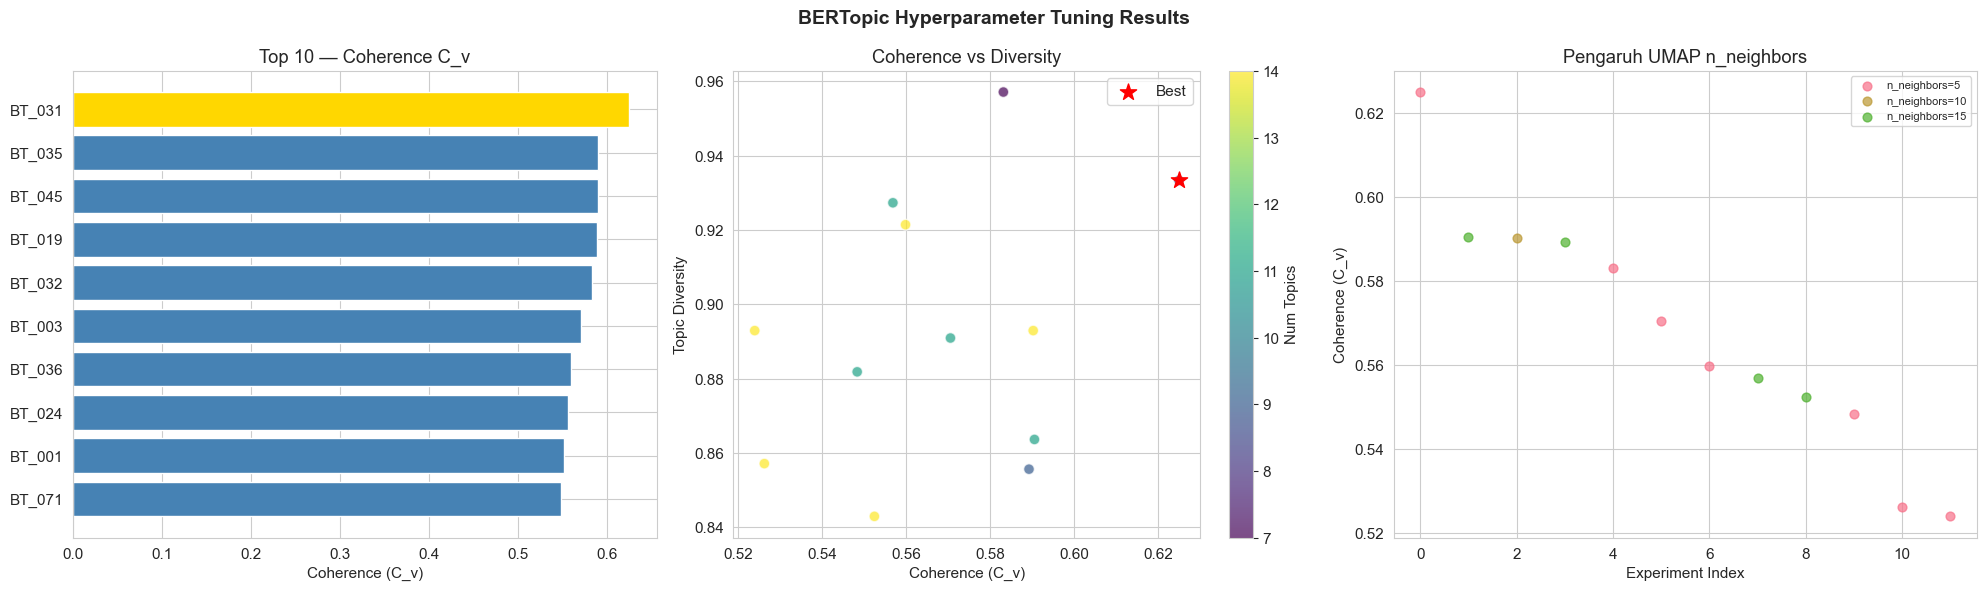

💾 Plot disimpan ke: step5_bertopic_tuning_results.png


In [32]:
# ============================================
# 5.3 Visualisasi BERTopic Tuning
# ============================================

if DATA_READY and len(df_bt_sorted) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("BERTopic Hyperparameter Tuning Results", fontsize=14, fontweight="bold")
    
    # 1. Top-10 Coherence bar chart
    ax1 = axes[0]
    top10 = df_bt_sorted.head(10)
    colors = ["gold" if i == 0 else "steelblue" for i in range(len(top10))]
    ax1.barh(top10["run_id"][::-1], top10["coherence_cv"][::-1], color=colors[::-1])
    ax1.set_xlabel("Coherence (C_v)")
    ax1.set_title("Top 10 — Coherence C_v")
    
    # 2. Coherence vs Diversity scatter
    ax2 = axes[1]
    sc = ax2.scatter(
        df_bt_sorted["coherence_cv"],
        df_bt_sorted["topic_diversity"],
        c=df_bt_sorted["num_topics"],
        cmap="viridis",
        s=60, alpha=0.7, edgecolors="white"
    )
    plt.colorbar(sc, ax=ax2, label="Num Topics")
    ax2.set_xlabel("Coherence (C_v)")
    ax2.set_ylabel("Topic Diversity")
    ax2.set_title("Coherence vs Diversity")
    # Highlight best
    ax2.scatter(
        [best_bt["coherence_cv"]], [best_bt["topic_diversity"]],
        color="red", s=150, marker="*", zorder=5, label="Best"
    )
    ax2.legend()
    
    # 3. Effect of n_neighbors on coherence
    ax3 = axes[2]
    for nn in sorted(df_bt_sorted["umap_n_neighbors"].unique()):
        subset = df_bt_sorted[df_bt_sorted["umap_n_neighbors"] == nn]
        ax3.scatter(
            subset.index, subset["coherence_cv"],
            label=f"n_neighbors={nn}", s=40, alpha=0.7
        )
    ax3.set_xlabel("Experiment Index")
    ax3.set_ylabel("Coherence (C_v)")
    ax3.set_title("Pengaruh UMAP n_neighbors")
    ax3.legend(fontsize=8)
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step5_bertopic_tuning_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step5_bertopic_tuning_results.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 6. 🔬 Hyperparameter Tuning — LDA

In [33]:
# ============================================
# 6.1 LDA Grid Search
# ============================================

if DATA_READY:
    from gensim.corpora import Dictionary
    from gensim.models import LdaMulticore, LdaModel
    from gensim.models.coherencemodel import CoherenceModel
    
    # Tokenize processed text (stemmed) untuk LDA
    tokenized_docs_lda = [doc.split() for doc in documents_stemmed]
    
    # Build grid combinations
    lg = CONFIG["lda_grid"]
    lda_param_keys = list(lg.keys())
    lda_param_values = list(lg.values())
    lda_combinations = list(product(*lda_param_values))
    
    print(f"🔬 Memulai LDA Grid Search: {len(lda_combinations)} kombinasi")
    print(f"   📌 Menggunakan LdaModel untuk alpha='auto' (auto-tuning)")
    print(f"   📌 Menggunakan LdaMulticore untuk kombinasi lainnya (lebih cepat)")
    print("="*70)
    
    lda_results = []
    csv_path_lda = OUTPUT_CSV_DIR / "step6_lda_tuning_results.csv"
    
    for idx, combo in enumerate(lda_combinations):
        params = dict(zip(lda_param_keys, combo))
        run_id = f"LDA_{idx+1:03d}"
        
        print(f"\n[{idx+1}/{len(lda_combinations)}] {run_id}: {params}")
        
        try:
            start = time.time()
            
            # Build dictionary & corpus
            dictionary = Dictionary(tokenized_docs_lda)
            dictionary.filter_extremes(
                no_below=params["no_below"],
                no_above=params["no_above"],
            )
            corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs_lda]
            
            # Parse alpha/eta
            alpha = params["alpha"]
            eta = params["eta"]
            
            # PERBAIKAN: Gunakan LdaModel jika alpha='auto', karena LdaMulticore tidak support
            use_multicore = alpha != 'auto' and eta != 'auto'
            
            if use_multicore:
                # Train LDA dengan multicore (lebih cepat)
                lda_model = LdaMulticore(
                    corpus=corpus,
                    id2word=dictionary,
                    num_topics=params["num_topics"],
                    passes=params["passes"],
                    iterations=400,
                    chunksize=100,
                    random_state=RANDOM_STATE,
                    alpha=alpha,
                    eta=eta,
                    per_word_topics=True,
                )
            else:
                # Train LDA dengan single core (support auto-tuning alpha/eta)
                lda_model = LdaModel(
                    corpus=corpus,
                    id2word=dictionary,
                    num_topics=params["num_topics"],
                    passes=params["passes"],
                    iterations=400,
                    random_state=RANDOM_STATE,
                    alpha=alpha,
                    eta=eta,
                    per_word_topics=True,
                )
            
            # Coherence C_v
            cm = CoherenceModel(
                model=lda_model,
                texts=tokenized_docs_lda,
                dictionary=dictionary,
                coherence="c_v",
            )
            coherence_cv = round(cm.get_coherence(), 4)
            
            # Topic Diversity
            topic_words_lda = []
            for tid in range(params["num_topics"]):
                words = [w for w, _ in lda_model.show_topic(tid, topn=CONFIG["top_n_words"])]
                topic_words_lda.append(words)
            
            all_w = [w for tw in topic_words_lda for w in tw]
            diversity = round(len(set(all_w)) / max(len(all_w), 1), 4)
            
            duration = round(time.time() - start, 2)
            
            result_row = {
                "run_id": run_id,
                **params,
                "num_topics_actual": params["num_topics"],
                "dictionary_size": len(dictionary),
                "coherence_cv": coherence_cv,
                "topic_diversity": diversity,
                "duration_sec": duration,
                "status": "success",
            }
            
            print(f"   ✅ Coherence: {coherence_cv} | Diversity: {diversity} | Dict: {len(dictionary)} | {duration}s")
            
        except Exception as e:
            result_row = {
                "run_id": run_id,
                **params,
                "num_topics_actual": params["num_topics"],
                "dictionary_size": 0,
                "coherence_cv": float('nan'),
                "topic_diversity": float('nan'),
                "duration_sec": 0,
                "status": f"error: {str(e)[:100]}",
            }
            print(f"   ❌ Error: {str(e)[:100]}")
        
        lda_results.append(result_row)
        
        # Simpan incremental
        pd.DataFrame(lda_results).to_csv(csv_path_lda, index=False)
    
    df_lda_results = pd.DataFrame(lda_results)
    print(f"\n{'='*70}")
    print(f"✅ LDA Grid Search selesai! {len(df_lda_results)} eksperimen.")
    print(f"💾 Hasil disimpan ke: step6_lda_tuning_results.csv")
else:
    print("⏭️ Langkah ini dilewati.")

🔬 Memulai LDA Grid Search: 40 kombinasi
   📌 Menggunakan LdaModel untuk alpha='auto' (auto-tuning)
   📌 Menggunakan LdaMulticore untuk kombinasi lainnya (lebih cepat)

[1/40] LDA_001: {'num_topics': 5, 'passes': 15, 'alpha': 'auto', 'eta': 'auto', 'no_below': 5, 'no_above': 0.5}
   ✅ Coherence: 0.3494 | Diversity: 0.78 | Dict: 1186 | 19.56s

[2/40] LDA_002: {'num_topics': 5, 'passes': 15, 'alpha': 'auto', 'eta': 'symmetric', 'no_below': 5, 'no_above': 0.5}
   ✅ Coherence: 0.3494 | Diversity: 0.78 | Dict: 1186 | 19.56s

[2/40] LDA_002: {'num_topics': 5, 'passes': 15, 'alpha': 'auto', 'eta': 'symmetric', 'no_below': 5, 'no_above': 0.5}
   ✅ Coherence: 0.3494 | Diversity: 0.78 | Dict: 1186 | 17.64s

[3/40] LDA_003: {'num_topics': 5, 'passes': 15, 'alpha': 'symmetric', 'eta': 'auto', 'no_below': 5, 'no_above': 0.5}
   ✅ Coherence: 0.3494 | Diversity: 0.78 | Dict: 1186 | 17.64s

[3/40] LDA_003: {'num_topics': 5, 'passes': 15, 'alpha': 'symmetric', 'eta': 'auto', 'no_below': 5, 'no_above': 0

In [34]:
# ============================================
# 6.2 LDA Tuning Results — Tabel
# ============================================

if DATA_READY:
    df_lda_sorted = df_lda_results[
        df_lda_results["status"] == "success"
    ].sort_values("coherence_cv", ascending=False).reset_index(drop=True)
    
    print("🏆 Top 10 Kombinasi LDA (berdasarkan Coherence C_v):")
    display(
        df_lda_sorted.head(10)[
            ["run_id", "num_topics", "passes", "alpha", "eta",
             "coherence_cv", "topic_diversity", "dictionary_size", "duration_sec"]
        ]
    )
    
    best_lda = df_lda_sorted.iloc[0]
    print(f"\n🥇 Parameter Terbaik LDA: {best_lda['run_id']}")
    print(f"   Coherence C_v     : {best_lda['coherence_cv']}")
    print(f"   Topic Diversity   : {best_lda['topic_diversity']}")
    print(f"   Jumlah Topik      : {best_lda['num_topics']}")
else:
    print("⏭️ Langkah ini dilewati.")

🏆 Top 10 Kombinasi LDA (berdasarkan Coherence C_v):


,run_id,num_topics,passes,alpha,eta,coherence_cv,topic_diversity,dictionary_size,duration_sec
0,LDA_039,15,20,symmetric,auto,0.4001,0.7067,1186,19.87
1,LDA_037,15,20,auto,auto,0.3994,0.7000,1186,20.34
2,LDA_038,15,20,auto,symmetric,0.3994,0.7000,1186,19.79
3,LDA_035,15,15,symmetric,auto,0.3978,0.6933,1186,17.18
4,LDA_034,15,15,auto,symmetric,0.3972,0.6933,1186,17.28
5,LDA_033,15,15,auto,auto,0.3972,0.6933,1186,17.39
6,LDA_040,15,20,symmetric,symmetric,0.3946,0.7200,1186,21.26
7,LDA_036,15,15,symmetric,symmetric,0.3911,0.7000,1186,21.08
8,LDA_032,12,20,symmetric,symmetric,0.3677,0.7250,1186,21.52
9,LDA_031,12,20,symmetric,auto,0.3634,0.7417,1186,20.51



🥇 Parameter Terbaik LDA: LDA_039
   Coherence C_v     : 0.4001
   Topic Diversity   : 0.7067
   Jumlah Topik      : 15


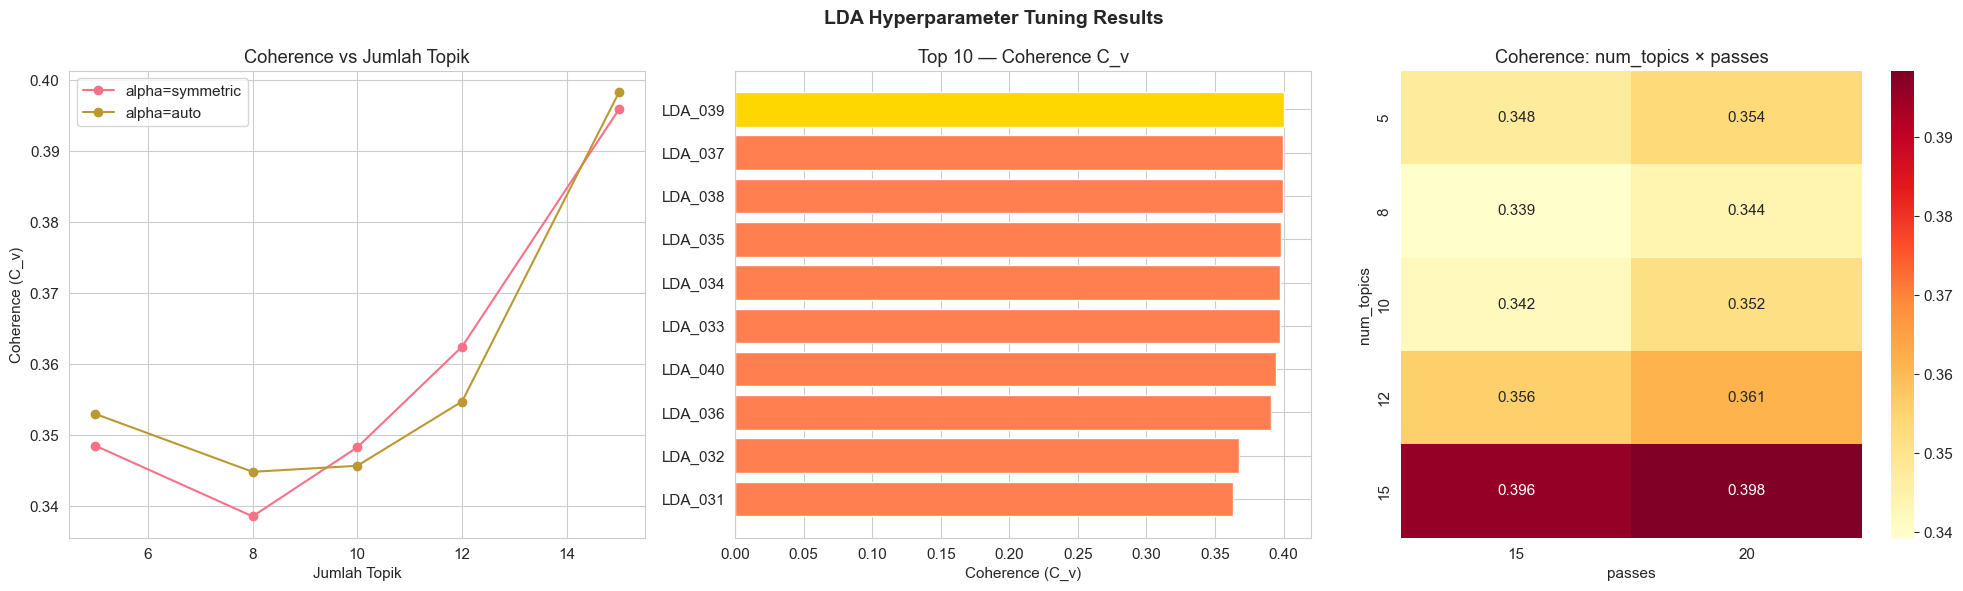

💾 Plot disimpan ke: step6_lda_tuning_results.png


In [35]:
# ============================================
# 6.3 Visualisasi LDA Tuning
# ============================================

if DATA_READY and len(df_lda_sorted) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("LDA Hyperparameter Tuning Results", fontsize=14, fontweight="bold")
    
    # 1. Coherence by num_topics
    ax1 = axes[0]
    for alpha_val in df_lda_sorted["alpha"].unique():
        subset = df_lda_sorted[df_lda_sorted["alpha"] == alpha_val]
        means = subset.groupby("num_topics")["coherence_cv"].mean()
        ax1.plot(means.index, means.values, marker='o', label=f"alpha={alpha_val}")
    ax1.set_xlabel("Jumlah Topik")
    ax1.set_ylabel("Coherence (C_v)")
    ax1.set_title("Coherence vs Jumlah Topik")
    ax1.legend()
    
    # 2. Top-10 bar chart
    ax2 = axes[1]
    top10_lda = df_lda_sorted.head(10)
    colors_lda = ["gold" if i == 0 else "coral" for i in range(len(top10_lda))]
    ax2.barh(top10_lda["run_id"][::-1], top10_lda["coherence_cv"][::-1], color=colors_lda[::-1])
    ax2.set_xlabel("Coherence (C_v)")
    ax2.set_title("Top 10 — Coherence C_v")
    
    # 3. Heatmap: num_topics vs passes
    ax3 = axes[2]
    pivot = df_lda_sorted.pivot_table(
        values="coherence_cv",
        index="num_topics",
        columns="passes",
        aggfunc="mean",
    )
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax3)
    ax3.set_title("Coherence: num_topics × passes")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step6_lda_tuning_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step6_lda_tuning_results.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 7. 🏋️ Training Model Terbaik

In [36]:
# =============================================== #
# 7.1 Training BERTopic dengan Parameter Terbaik  #
# =============================================== #

if DATA_READY:
    print("🏋️ Training BERTopic Final Model dengan parameter terbaik...")
    show_cols = ['umap_n_neighbors', 'umap_n_components', 'umap_min_dist',
                 'hdbscan_min_cluster_size', 'min_topic_size', 'nr_topics']
    show_cols_existing = [c for c in show_cols if c in best_bt.index]
    print(f"   Parameter: {best_bt[show_cols_existing].to_dict()}")
    print(f"   CountVectorizer: stop_words={len(stopword_list)}, min_df=2, max_df=0.95, token ≥ 3 char")

    start = time.time()

    # nr_topics dari best_bt (hard cap untuk merge topik)
    nr_topics_val = int(best_bt["nr_topics"]) if "nr_topics" in best_bt.index and pd.notna(best_bt.get("nr_topics")) else None
    print(f"   nr_topics (hard cap)  : {nr_topics_val}")

    # Build model dengan parameter terbaik
    best_umap = UMAP(
        n_neighbors=int(best_bt["umap_n_neighbors"]),
        n_components=int(best_bt["umap_n_components"]),
        min_dist=float(best_bt["umap_min_dist"]),
        metric=str(best_bt["umap_metric"]) if "umap_metric" in best_bt.index else "cosine",
        random_state=RANDOM_STATE,
    )

    best_hdbscan = HDBSCAN(
        min_cluster_size=int(best_bt["hdbscan_min_cluster_size"]),
        min_samples=int(best_bt["hdbscan_min_samples"]) if "hdbscan_min_samples" in best_bt.index and pd.notna(best_bt.get("hdbscan_min_samples")) else None,
        metric=str(best_bt["hdbscan_metric"]) if "hdbscan_metric" in best_bt.index else "euclidean",
        cluster_selection_method=str(best_bt["hdbscan_method"]) if "hdbscan_method" in best_bt.index else "eom",
        prediction_data=True,
    )

    # CountVectorizer — KONSISTEN dengan grid search (min_df=2, max_df=0.95)
    # Ini penting karena cluster BERTopic bisa sangat kecil (2-5 dokumen),
    # sehingga max_df yang terlalu ketat menyebabkan error
    # "max_df corresponds to < documents than min_df"
    best_vectorizer = CountVectorizer(
        ngram_range=(1, 2),
        stop_words=stopword_list,
        min_df=2,
        max_df=0.95,
        token_pattern=r"(?u)\b\w{3,}\b",
    )

    # ============================================
    # Representation Model: MMR (Maximal Marginal Relevance)
    # ============================================
    # MMR fine-tunes representasi topik SETELAH c-TF-IDF dihitung.
    # Pipeline: CountVectorizer → c-TF-IDF (default) → MMR (fine-tuning)
    #
    # MMR mendiversifikasi kata-kata dalam representasi topik:
    # - Tanpa MMR: bisa muncul kata mirip seperti "sistem", "sistem informasi" 
    #   yang redundan di satu topik
    # - Dengan MMR: kata-kata dipilih agar beragam (diverse), meningkatkan 
    #   Topic Diversity score
    #
    # diversity=0.3 → moderate diversification (0=no diversity, 1=max diversity)
    mmr_model = MaximalMarginalRelevance(diversity=0.3)
    print(f"   Representation Model : MMR (diversity=0.3)")

    final_bt_model = BERTopic(
        embedding_model=st_model,
        umap_model=best_umap,
        hdbscan_model=best_hdbscan,
        vectorizer_model=best_vectorizer,
        representation_model=mmr_model,   # Fine-tune c-TF-IDF dengan MMR
        top_n_words=CONFIG["top_n_words"],
        min_topic_size=int(best_bt["min_topic_size"]),
        nr_topics=nr_topics_val,   # hard cap dari grid search terbaik
        verbose=True,
    )

    bt_topics, bt_probs = final_bt_model.fit_transform(documents_cleaned, embeddings=embeddings)

    bt_duration = round(time.time() - start, 2)
    bt_topic_info = final_bt_model.get_topic_info()
    bt_num_topics = len(bt_topic_info) - 1
    bt_outliers_before = int((np.array(bt_topics) == -1).sum())

    print(f"\n📊 BERTopic SEBELUM reduce_outliers:")
    print(f"   Topik ditemukan : {bt_num_topics}")
    print(f"   nr_topics cap   : {nr_topics_val}")
    print(f"   Outliers        : {bt_outliers_before} ({bt_outliers_before/len(documents_cleaned)*100:.1f}%)")
    print(f"   Durasi          : {bt_duration}s")

    # ============================================
    # 7.1b Reduce Outliers menggunakan strategi bertahap
    # ============================================
    # BERTopic sering menghasilkan banyak outlier (topik -1) karena HDBSCAN
    # hanya mengelompokkan titik-titik yang benar-benar padat.
    # reduce_outliers() re-assign outlier ke topik terdekat.
    #
    # Strategi bertahap:
    #   1. "c-tf-idf" — assign outlier ke topik terdekat berdasarkan representasi c-TF-IDF
    #      (threshold=0.1 → cukup longgar, assign sebanyak mungkin)
    #   2. "distributions" — untuk outlier yang tersisa, gunakan distribusi probabilitas

    print(f"\n⏳ Menjalankan reduce_outliers (strategi bertahap)...")
    
    # Tahap 1: c-TF-IDF based (paling akurat)
    bt_topics_reduced = final_bt_model.reduce_outliers(
        documents_cleaned, 
        bt_topics, 
        strategy="c-tf-idf",
        threshold=0.1,  # 0.1 = cukup longgar → assign lebih banyak outlier
    )
    outliers_after_ctfidf = int((np.array(bt_topics_reduced) == -1).sum())
    print(f"   Setelah c-TF-IDF  : {outliers_after_ctfidf} outliers ({outliers_after_ctfidf/len(documents_cleaned)*100:.1f}%)")
    
    # Tahap 2: Distribution-based (untuk outlier yang tersisa)
    if outliers_after_ctfidf > 0:
        bt_topics_reduced = final_bt_model.reduce_outliers(
            documents_cleaned,
            bt_topics_reduced,
            strategy="distributions",
            threshold=0.05,  # probabilitas minimum untuk assign ke topik
        )
        outliers_after_dist = int((np.array(bt_topics_reduced) == -1).sum())
        print(f"   Setelah distributions: {outliers_after_dist} outliers ({outliers_after_dist/len(documents_cleaned)*100:.1f}%)")
    
    # Update topik di model — PENTING: sertakan vectorizer_model DAN representation_model!
    # Tanpa vectorizer_model, BERTopic akan menggunakan default CountVectorizer
    # yang TIDAK menghapus stopwords, sehingga representasi topik dipenuhi
    # kata seperti "yang", "dan", "dengan" → CV dan diversity anjlok.
    # Tanpa representation_model, MMR fine-tuning tidak diterapkan ulang.
    final_bt_model.update_topics(
        documents_cleaned, 
        topics=bt_topics_reduced,
        vectorizer_model=best_vectorizer,       # gunakan vectorizer yg sama (dengan stopwords removal)
        representation_model=mmr_model,          # terapkan ulang MMR fine-tuning
    )
    bt_topics = bt_topics_reduced
    
    # Recalculate stats
    bt_topic_info = final_bt_model.get_topic_info()
    bt_num_topics = len(bt_topic_info) - 1
    bt_outliers = int((np.array(bt_topics) == -1).sum())

    print(f"\n✅ BERTopic Final Model selesai (SETELAH reduce_outliers)!")
    print(f"   Topik final     : {bt_num_topics}")
    print(f"   Outliers awal   : {bt_outliers_before} ({bt_outliers_before/len(documents_cleaned)*100:.1f}%)")
    print(f"   Outliers final  : {bt_outliers} ({bt_outliers/len(documents_cleaned)*100:.1f}%)")
    print(f"   Outliers reduced: {bt_outliers_before - bt_outliers} dokumen berhasil di-assign")
    print(f"   Durasi          : {bt_duration}s")

    # Simpan topic info
    bt_topic_info.to_csv(OUTPUT_CSV_DIR / "step7_bertopic_final_topic_info.csv", index=False)
    print(f"💾 Topic info disimpan ke: step7_bertopic_final_topic_info.csv")
    display(bt_topic_info.head(15))
else:
    print("⏭️ Langkah ini dilewati.")

2026-03-07 06:38:09,099 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


🏋️ Training BERTopic Final Model dengan parameter terbaik...
   Parameter: {'umap_n_neighbors': 5, 'umap_n_components': 5, 'umap_min_dist': 0.0, 'hdbscan_min_cluster_size': 5, 'min_topic_size': 5, 'nr_topics': 10}
   CountVectorizer: stop_words=774, min_df=2, max_df=0.95, token ≥ 3 char
   nr_topics (hard cap)  : 10
   Representation Model : MMR (diversity=0.3)


2026-03-07 06:38:10,050 - BERTopic - Dimensionality - Completed ✓
2026-03-07 06:38:10,057 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-07 06:38:10,057 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-07 06:38:10,142 - BERTopic - Cluster - Completed ✓
2026-03-07 06:38:10,144 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-07 06:38:10,142 - BERTopic - Cluster - Completed ✓
2026-03-07 06:38:10,144 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-07 06:38:10,729 - BERTopic - Representation - Completed ✓
2026-03-07 06:38:10,732 - BERTopic - Topic reduction - Reducing number of topics
2026-03-07 06:38:10,729 - BERTopic - Representation - Completed ✓
2026-03-07 06:38:10,732 - BERTopic - Topic reduction - Reducing number of topics
2026-03-07 06:38:10,797 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-07 06:38:10,797 - BERT


📊 BERTopic SEBELUM reduce_outliers:
   Topik ditemukan : 9
   nr_topics cap   : 10
   Outliers        : 42 (8.9%)
   Durasi          : 45.41s

⏳ Menjalankan reduce_outliers (strategi bertahap)...
   Setelah c-TF-IDF  : 5 outliers (1.1%)


100%|██████████| 1/1 [00:00<00:00, 44.47it/s]
2026-03-07 06:38:54,880 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.

2026-03-07 06:38:54,880 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


   Setelah distributions: 0 outliers (0.0%)

✅ BERTopic Final Model selesai (SETELAH reduce_outliers)!
   Topik final     : 8
   Outliers awal   : 42 (8.9%)
   Outliers final  : 0 (0.0%)
   Outliers reduced: 42 dokumen berhasil di-assign
   Durasi          : 45.41s
💾 Topic info disimpan ke: step7_bertopic_final_topic_info.csv

✅ BERTopic Final Model selesai (SETELAH reduce_outliers)!
   Topik final     : 8
   Outliers awal   : 42 (8.9%)
   Outliers final  : 0 (0.0%)
   Outliers reduced: 42 dokumen berhasil di-assign
   Durasi          : 45.41s
💾 Topic info disimpan ke: step7_bertopic_final_topic_info.csv


,Topic,Count,Name,Representation,Representative_Docs
0,0,270,0_model_laravel_implementasi_pengelolaan,"[model, laravel, implementasi, pengelolaan, an...",[analisis kinerja web server laravel octane pa...
1,1,104,1_purbalingga_penjualan_umkm_desa,"[purbalingga, penjualan, umkm, desa, waterfall...",[rancang bangun sistem informasi inventaris da...
2,2,27,2_edukasi_pembelajaran_pemain_development life,"[edukasi, pembelajaran, pemain, development li...",[rancang bangun game edukasi 3d berbasis andro...
3,3,18,3_purbalingga_budaya_objek_marketplace,"[purbalingga, budaya, objek, marketplace, peny...",[implementasi metode electre dalam sistem reko...
4,4,20,4_analisis sentimen_naïve_negatif_naïve bayes,"[analisis sentimen, naïve, negatif, naïve baye...",[analisis sentimen ulasan game apex legends pa...
5,5,9,5_negeri_guru_waterfall_sokaraja,"[negeri, guru, waterfall, sokaraja, reporting,...",[sistem informasi sekolah berbasis web dilengk...
6,6,7,6_isyarat_menunjukan_yolov8_suara,"[isyarat, menunjukan, yolov8, suara, cerdas, e...",[model deep learning yolo v11 untuk deteksi ob...
7,7,8,7_nasabah_segmentasi_optimal_algoritma means,"[nasabah, segmentasi, optimal, algoritma means...",[segmentasi pelanggan dan penentuan rekomendas...
8,8,8,8_forward chaining_pakar identifikasi_peternak...,"[forward chaining, pakar identifikasi, peterna...",[rancang bangun sistem pakar identifikasi peny...


In [37]:
# ============================================
# 7.2 Training LDA dengan Parameter Terbaik
# ============================================

if DATA_READY:
    print("🏋️ Training LDA Final Model dengan parameter terbaik...")
    print(f"   Parameter: num_topics={best_lda['num_topics']}, passes={best_lda['passes']}, alpha={best_lda['alpha']}, eta={best_lda['eta']}")
    
    start = time.time()
    
    # Build dictionary & corpus
    final_lda_dict = Dictionary(tokenized_docs_lda)
    final_lda_dict.filter_extremes(
        no_below=int(best_lda["no_below"]),
        no_above=float(best_lda["no_above"]),
    )
    final_lda_corpus = [final_lda_dict.doc2bow(doc) for doc in tokenized_docs_lda]
    
    # Train
    final_lda_model = LdaMulticore(
        corpus=final_lda_corpus,
        id2word=final_lda_dict,
        num_topics=int(best_lda["num_topics"]),
        passes=int(best_lda["passes"]),
        iterations=400,
        chunksize=100,
        random_state=RANDOM_STATE,
        alpha=best_lda["alpha"],
        eta=best_lda["eta"],
        per_word_topics=True,
    )
    
    lda_duration = round(time.time() - start, 2)
    
    # Extract topic words
    lda_topic_records = []
    for tid in range(int(best_lda["num_topics"])):
        words_scores = final_lda_model.show_topic(tid, topn=CONFIG["top_n_words"])
        lda_topic_records.append({
            "topic_id": tid,
            "top_words": ", ".join([w for w, _ in words_scores]),
            "word_scores": ", ".join([f"{s:.4f}" for _, s in words_scores]),
        })
    
    df_lda_topics = pd.DataFrame(lda_topic_records)
    df_lda_topics.to_csv(OUTPUT_CSV_DIR / "step7_lda_final_topic_info.csv", index=False)
    
    print(f"\n✅ LDA Final Model selesai!")
    print(f"   Topik           : {int(best_lda['num_topics'])}")
    print(f"   Dictionary size : {len(final_lda_dict)}")
    print(f"   Durasi          : {lda_duration}s")
    print(f"💾 Topic info disimpan ke: step7_lda_final_topic_info.csv")
    display(df_lda_topics)
else:
    print("⏭️ Langkah ini dilewati.")

🏋️ Training LDA Final Model dengan parameter terbaik...
   Parameter: num_topics=15, passes=20, alpha=symmetric, eta=auto

✅ LDA Final Model selesai!
   Topik           : 15
   Dictionary size : 1186
   Durasi          : 32.77s
💾 Topic info disimpan ke: step7_lda_final_topic_info.csv

✅ LDA Final Model selesai!
   Topik           : 15
   Dictionary size : 1186
   Durasi          : 32.77s
💾 Topic info disimpan ke: step7_lda_final_topic_info.csv


,topic_id,top_words,word_scores
0,0,"putus, nilai, dukung, tentu, kerja, bantu, ter...","0.0437, 0.0383, 0.0283, 0.0248, 0.0247, 0.0215..."
1,1,"pakar, kelola, lapor, kerja, website, sakit, s...","0.0219, 0.0193, 0.0191, 0.0190, 0.0148, 0.0144..."
2,2,"game, ajar, edukasi, main, siswa, tingkat, nil...","0.0780, 0.0462, 0.0263, 0.0248, 0.0239, 0.0221..."
3,3,"model, prediksi, nilai, harga, akurasi, random...","0.1133, 0.0648, 0.0244, 0.0233, 0.0190, 0.0171..."
4,4,"user, website, rekomendasi, tingkat, interface...","0.0375, 0.0259, 0.0184, 0.0172, 0.0168, 0.0163..."
5,5,"aplikasi, layan, tingkat, jasa, kelola, daerah...","0.0605, 0.0246, 0.0200, 0.0194, 0.0166, 0.0147..."
6,6,"jual, produk, transaksi, umkm, nilai, kelompok...","0.0364, 0.0277, 0.0207, 0.0179, 0.0165, 0.0159..."
7,7,"model, nilai, klasifikasi, sentimen, akurasi, ...","0.0401, 0.0399, 0.0363, 0.0303, 0.0256, 0.0240..."
8,8,"kelola, teknik, fakultas, kerja, tanah, sehat,...","0.0311, 0.0263, 0.0236, 0.0207, 0.0206, 0.0206..."
9,9,"aplikasi, nilai, arsitektur, flutter, mobil, m...","0.0603, 0.0147, 0.0146, 0.0139, 0.0125, 0.0119..."


---
## 8. 📏 Evaluasi & Perbandingan Model

In [38]:

# ============================================
# 8.1 Evaluasi BERTopic Final
# ============================================

if DATA_READY:
    # BERTopic Coherence
    bt_topic_words = []
    for tid in final_bt_model.get_topics():
        if tid == -1:
            continue
        words = [w for w, _ in final_bt_model.get_topic(tid)]
        bt_topic_words.append(words)
    
    bt_cm = CoherenceModel(
        topics=bt_topic_words,
        texts=tokenized_docs_cleaned,
        dictionary=gensim_dict_cleaned,
        coherence="c_v",
    )
    bt_final_coherence = round(bt_cm.get_coherence(), 4)
    
    # BERTopic Diversity
    bt_all_w = [w for tw in bt_topic_words for w in tw[:CONFIG["top_n_words"]]]
    bt_final_diversity = round(len(set(bt_all_w)) / max(len(bt_all_w), 1), 4)
    
    # LDA Coherence
    lda_cm = CoherenceModel(
        model=final_lda_model,
        texts=tokenized_docs_lda,
        dictionary=final_lda_dict,
        coherence="c_v",
    )
    lda_final_coherence = round(lda_cm.get_coherence(), 4)
    
    # LDA Diversity
    lda_tw = []
    for tid in range(int(best_lda["num_topics"])):
        words = [w for w, _ in final_lda_model.show_topic(tid, topn=CONFIG["top_n_words"])]
        lda_tw.append(words)
    lda_all_w = [w for tw in lda_tw for w in tw]
    lda_final_diversity = round(len(set(lda_all_w)) / max(len(lda_all_w), 1), 4)
    
    # === Tabel Perbandingan ===
    comparison = pd.DataFrame({
        "Metrik": [
            "Model",
            "Embedding",
            "Jumlah Topik",
            "Coherence (C_v) ↑",
            "Topic Diversity ↑",
            "Outliers",
            "Durasi Training (s)",
        ],
        "BERTopic": [
            "BERTopic (IndoSBERT → UMAP → HDBSCAN → c-TF-IDF + MMR)",
            "denaya/indoSBERT-large (256-dim output)",
            bt_num_topics,
            bt_final_coherence,
            bt_final_diversity,
            f"{bt_outliers} ({bt_outliers/len(documents_cleaned)*100:.1f}%) [sebelum reduce: {bt_outliers_before}]",
            bt_duration,
        ],
        "LDA": [
            "LDA (Gensim LdaMulticore)",
            "Bag-of-Words (TF)",
            int(best_lda["num_topics"]),
            lda_final_coherence,
            lda_final_diversity,
            "N/A",
            lda_duration,
        ],
    })
    
    comparison.to_csv(OUTPUT_CSV_DIR / "step8_model_comparison.csv", index=False)
    print("💾 Perbandingan disimpan ke: step8_model_comparison.csv\n")
    
    print("📊 PERBANDINGAN BERTopic vs LDA:")
    display(comparison)
    
    coherence_winner = "BERTopic" if bt_final_coherence > lda_final_coherence else "LDA"
    diversity_winner = "BERTopic" if bt_final_diversity > lda_final_diversity else "LDA"
    print(f"\n🏆 Coherence Winner  : {coherence_winner} (diff={abs(bt_final_coherence - lda_final_coherence):.4f})")
    print(f"🏆 Diversity Winner  : {diversity_winner} (diff={abs(bt_final_diversity - lda_final_diversity):.4f})")
else:
    print("⏭️ Langkah ini dilewati.")


💾 Perbandingan disimpan ke: step8_model_comparison.csv

📊 PERBANDINGAN BERTopic vs LDA:


,Metrik,BERTopic,LDA
0,Model,BERTopic (IndoSBERT → UMAP → HDBSCAN → c-TF-ID...,LDA (Gensim LdaMulticore)
1,Embedding,denaya/indoSBERT-large (256-dim output),Bag-of-Words (TF)
2,Jumlah Topik,8,15
3,Coherence (C_v) ↑,0.5355,0.395
4,Topic Diversity ↑,0.9333,0.7133
5,Outliers,0 (0.0%) [sebelum reduce: 42],N/A
6,Durasi Training (s),45.41,32.77



🏆 Coherence Winner  : BERTopic (diff=0.1405)
🏆 Diversity Winner  : BERTopic (diff=0.2200)


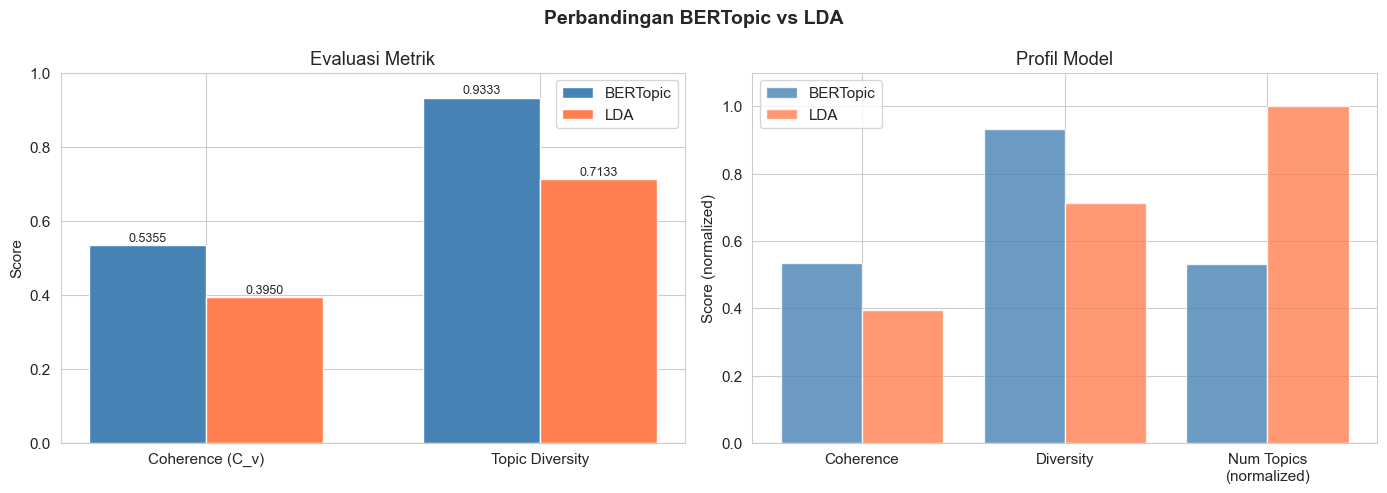

💾 Plot disimpan ke: step8_model_comparison.png


In [39]:
# ============================================
# 8.2 Visualisasi Perbandingan
# ============================================

if DATA_READY:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Perbandingan BERTopic vs LDA", fontsize=14, fontweight="bold")
    
    # 1. Bar chart: Coherence & Diversity
    ax1 = axes[0]
    metrics_names = ["Coherence (C_v)", "Topic Diversity"]
    bt_vals = [bt_final_coherence, bt_final_diversity]
    lda_vals = [lda_final_coherence, lda_final_diversity]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    bars1 = ax1.bar(x - width/2, bt_vals, width, label="BERTopic", color="steelblue")
    bars2 = ax1.bar(x + width/2, lda_vals, width, label="LDA", color="coral")
    
    ax1.set_ylabel("Score")
    ax1.set_title("Evaluasi Metrik")
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_names)
    ax1.legend()
    ax1.set_ylim(0, 1)
    
    # Annotate
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.4f}", ha='center', fontsize=9)
    for bar in bars2:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.4f}", ha='center', fontsize=9)
    
    # 2. Radar-style comparison (simple)
    ax2 = axes[1]
    categories = ["Coherence", "Diversity", "Num Topics\n(normalized)"]
    max_topics = max(bt_num_topics, int(best_lda["num_topics"]))
    bt_radar = [bt_final_coherence, bt_final_diversity, bt_num_topics / max_topics]
    lda_radar = [lda_final_coherence, lda_final_diversity, int(best_lda["num_topics"]) / max_topics]
    
    x_pos = np.arange(len(categories))
    ax2.bar(x_pos - 0.2, bt_radar, 0.4, label="BERTopic", color="steelblue", alpha=0.8)
    ax2.bar(x_pos + 0.2, lda_radar, 0.4, label="LDA", color="coral", alpha=0.8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(categories)
    ax2.set_ylabel("Score (normalized)")
    ax2.set_title("Profil Model")
    ax2.legend()
    ax2.set_ylim(0, 1.1)
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step8_model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step8_model_comparison.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 9. 📈 Dynamic Topic Analysis (DTA) — Evolusi Topik per Tahun

In [40]:
# ============================================
# 9.1 BERTopic — Topics Over Time
# ============================================

if DATA_READY and "year" in df_processed.columns:
    timestamps = df_processed["year"].tolist()
    
    print("📈 Menjalankan Dynamic Topic Analysis (BERTopic topics_over_time)...")
    topics_over_time = final_bt_model.topics_over_time(
        documents_cleaned,
        timestamps=timestamps,
    )
    
    # Simpan ke CSV
    topics_over_time.to_csv(OUTPUT_CSV_DIR / "step9_topics_over_time.csv", index=False)
    print(f"✅ Topics over time: {len(topics_over_time)} records")
    print(f"💾 Disimpan ke: step9_topics_over_time.csv")
    display(topics_over_time.head(20))
else:
    print("⏭️ Langkah ini dilewati (data atau kolom year tidak tersedia).")

📈 Menjalankan Dynamic Topic Analysis (BERTopic topics_over_time)...


9it [02:27, 16.38s/it]



✅ Topics over time: 53 records
💾 Disimpan ke: step9_topics_over_time.csv


,Topic,Words,Frequency,Timestamp
0,0,"organisasi, daerah, pendukung keputusan, penil...",22,2018
1,1,"berbasis web, penjualan, pengelolaan, kabupate...",20,2018
2,3,"budaya, wisata, based service, menginap, kabup...",1,2018
3,5,"reporting, online berbasis, siswa smk, negeri ...",2,2018
4,8,"kelinci, forward chaining, tulang, pakar ident...",2,2018
5,0,"tanah, aplikasi, monitoring, kepegawaian, wate...",16,2019
6,1,"berbasis web, mysql, desa, rancang bangun, pem...",19,2019
7,3,"penyedia jasa, mobil, event, rute terbaik, obj...",5,2019
8,4,"membership, pengenalan wajah, jaringan syaraf,...",2,2019
9,5,"pengembangan pendidikan, pengelolaan, negeri p...",2,2019


In [41]:
# ============================================
# 9.2 Trend Analysis — Emerging, Declining, Stable
# ============================================

if DATA_READY and "year" in df_processed.columns:
    from scipy import stats as scipy_stats
    
    # Analisis tren per topik
    trend_records = []
    
    for topic_id in topics_over_time["Topic"].unique():
        if topic_id == -1:
            continue
        
        topic_data = topics_over_time[topics_over_time["Topic"] == topic_id].copy()
        topic_data = topic_data.sort_values("Timestamp")
        
        if len(topic_data) < 2:
            continue
        
        # Linear regression untuk menentukan tren
        years_numeric = pd.to_numeric(topic_data["Timestamp"].astype(str).str[:4], errors='coerce')
        if years_numeric.isna().all():
            years_numeric = np.arange(len(topic_data))
        
        frequencies = topic_data["Frequency"].values
        
        if len(years_numeric) >= 2:
            slope, intercept, r_val, p_val, std_err = scipy_stats.linregress(
                years_numeric.values, frequencies
            )
        else:
            slope, r_val, p_val = 0, 0, 1
        
        # Klasifikasi tren
        if slope > 0.5 and p_val < 0.3:
            trend = "emerging"
        elif slope < -0.5 and p_val < 0.3:
            trend = "declining"
        else:
            trend = "stable"
        
        # Get topic words
        words = topic_data["Words"].iloc[0] if "Words" in topic_data.columns else ""
        
        trend_records.append({
            "topic_id": topic_id,
            "top_words": words,
            "trend": trend,
            "slope": round(slope, 4),
            "r_squared": round(r_val**2, 4),
            "p_value": round(p_val, 4),
            "avg_frequency": round(frequencies.mean(), 2),
            "min_frequency": int(frequencies.min()),
            "max_frequency": int(frequencies.max()),
        })
    
    df_trends = pd.DataFrame(trend_records)
    df_trends.to_csv(OUTPUT_CSV_DIR / "step9_topic_trends.csv", index=False)
    
    print("📈 Hasil Analisis Tren Topik:")
    print(f"   Emerging  : {len(df_trends[df_trends['trend'] == 'emerging'])} topik")
    print(f"   Declining : {len(df_trends[df_trends['trend'] == 'declining'])} topik")
    print(f"   Stable    : {len(df_trends[df_trends['trend'] == 'stable'])} topik")
    print(f"\n💾 Disimpan ke: step9_topic_trends.csv")
    display(df_trends)
else:
    print("⏭️ Langkah ini dilewati.")

📈 Hasil Analisis Tren Topik:
   Emerging  : 1 topik
   Declining : 2 topik
   Stable    : 6 topik

💾 Disimpan ke: step9_topic_trends.csv


,topic_id,top_words,trend,slope,r_squared,p_value,avg_frequency,min_frequency,max_frequency
0,0,"organisasi, daerah, pendukung keputusan, penil...",emerging,4.1667,0.3267,0.1078,30.00,10,67
1,1,"berbasis web, penjualan, pengelolaan, kabupate...",declining,-2.7857,0.5991,0.0242,13.00,1,26
2,3,"budaya, wisata, based service, menginap, kabup...",stable,0.1786,0.0568,0.6067,2.57,1,5
3,5,"reporting, online berbasis, siswa smk, negeri ...",stable,-0.1000,0.1071,0.5908,1.80,1,3
4,8,"kelinci, forward chaining, tulang, pakar ident...",stable,-0.1242,0.3106,0.2506,1.33,1,2
5,4,"membership, pengenalan wajah, jaringan syaraf,...",stable,0.1471,0.0221,0.7789,3.33,1,7
6,2,"heuristic evaluation, evaluation, heuristic, g...",stable,0.4286,0.0675,0.6191,4.50,1,9
7,6,"pengenalan suara, markov, kecerdasan buatan, a...",stable,0.2647,0.1765,0.5799,1.75,1,4
8,7,"segmentasi, nasabah, means clustering, area, i...",declining,-2.0000,1.0000,0.0000,4.00,3,5


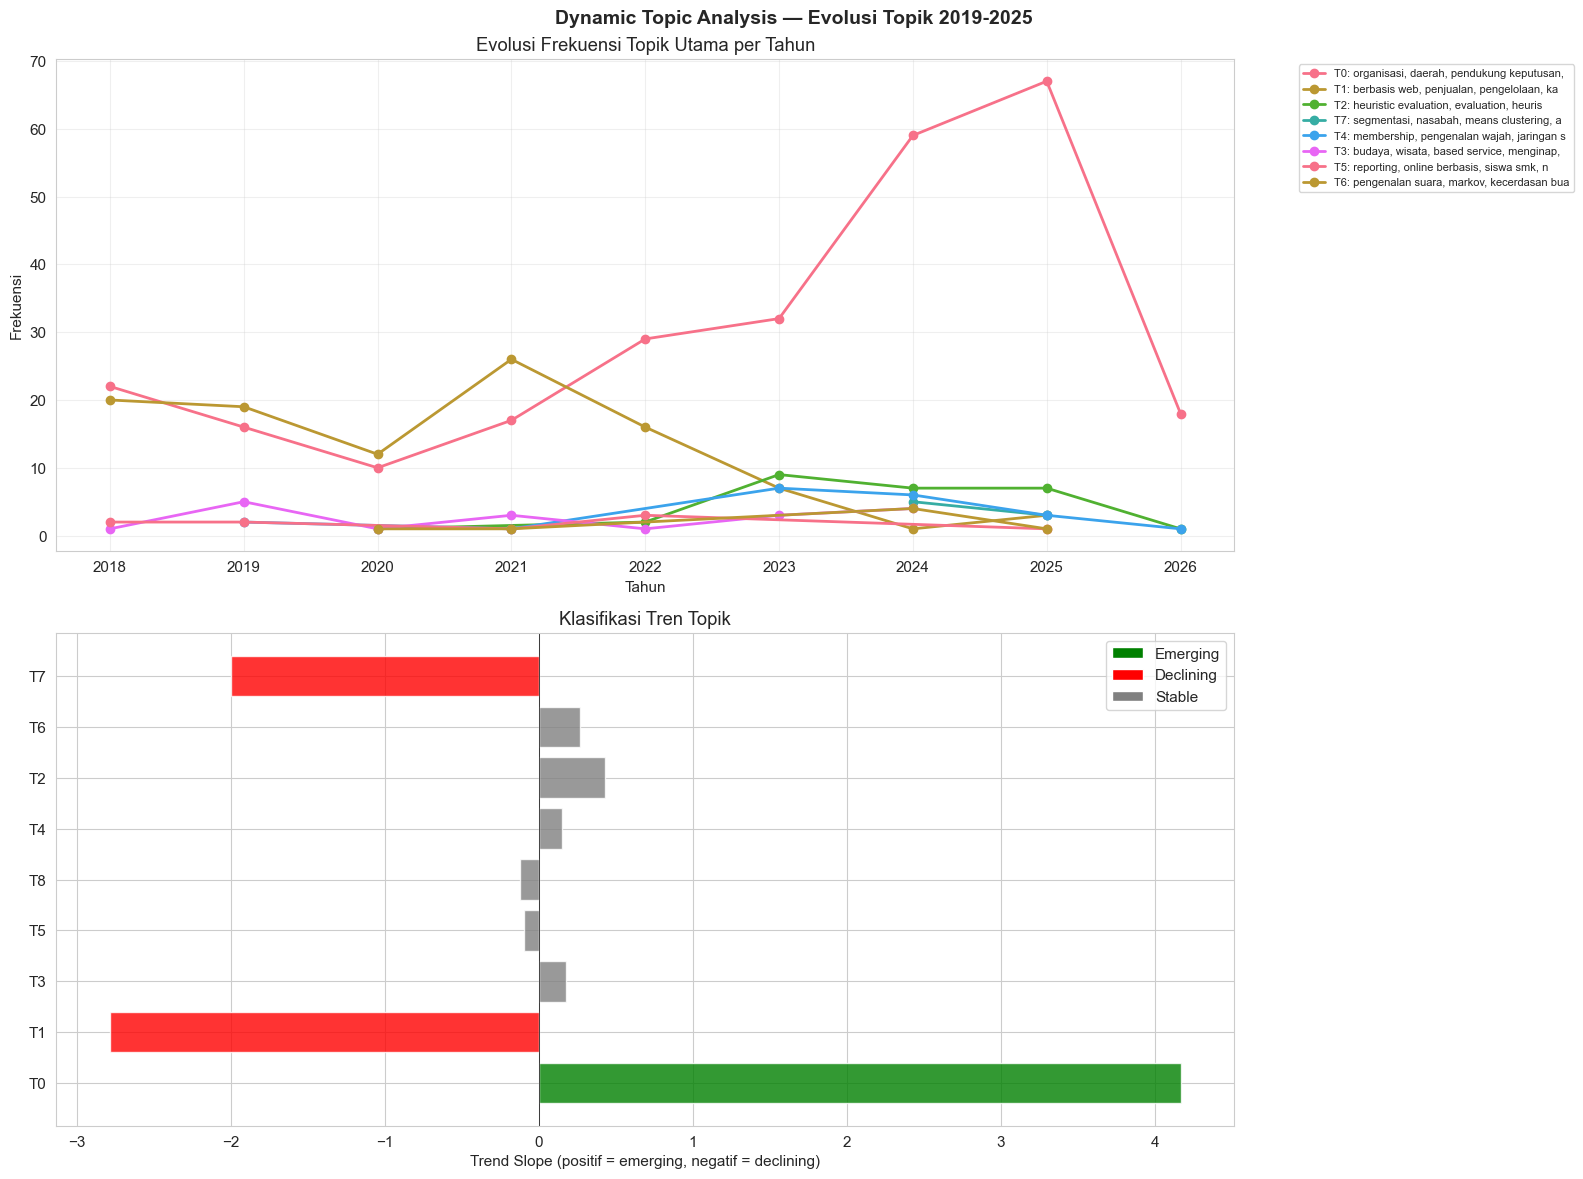

💾 Plot disimpan ke: step9_dynamic_topic_analysis.png


In [42]:
# ============================================
# 9.3 Visualisasi DTA
# ============================================

if DATA_READY and "year" in df_processed.columns and len(trend_records) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle("Dynamic Topic Analysis — Evolusi Topik 2019-2025", fontsize=14, fontweight="bold")
    
    # 1. Topics over time (line chart)
    ax1 = axes[0]
    # Ambil top-N topik berdasarkan rata-rata frekuensi
    top_topics = df_trends.nlargest(8, "avg_frequency")["topic_id"].tolist()
    
    for tid in top_topics:
        t_data = topics_over_time[topics_over_time["Topic"] == tid].sort_values("Timestamp")
        label_words = t_data["Words"].iloc[0][:40] if "Words" in t_data.columns else f"Topic {tid}"
        years_plot = pd.to_numeric(t_data["Timestamp"].astype(str).str[:4], errors='coerce')
        ax1.plot(years_plot, t_data["Frequency"].values, marker='o', linewidth=2, label=f"T{tid}: {label_words}")
    
    ax1.set_xlabel("Tahun")
    ax1.set_ylabel("Frekuensi")
    ax1.set_title("Evolusi Frekuensi Topik Utama per Tahun")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Trend classification bar
    ax2 = axes[1]
    trend_colors = {"emerging": "green", "declining": "red", "stable": "gray"}
    colors_trend = [trend_colors.get(t, "gray") for t in df_trends["trend"]]
    ax2.barh(
        [f"T{r['topic_id']}" for _, r in df_trends.iterrows()],
        df_trends["slope"],
        color=colors_trend,
        alpha=0.8
    )
    ax2.axvline(x=0, color='black', linewidth=0.5)
    ax2.set_xlabel("Trend Slope (positif = emerging, negatif = declining)")
    ax2.set_title("Klasifikasi Tren Topik")
    
    # Legend manual
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', label='Emerging'),
        Patch(facecolor='red', label='Declining'),
        Patch(facecolor='gray', label='Stable'),
    ]
    ax2.legend(handles=legend_elements)
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step9_dynamic_topic_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Plot disimpan ke: step9_dynamic_topic_analysis.png")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 10. ☁️ Word Cloud & Visualisasi Topik

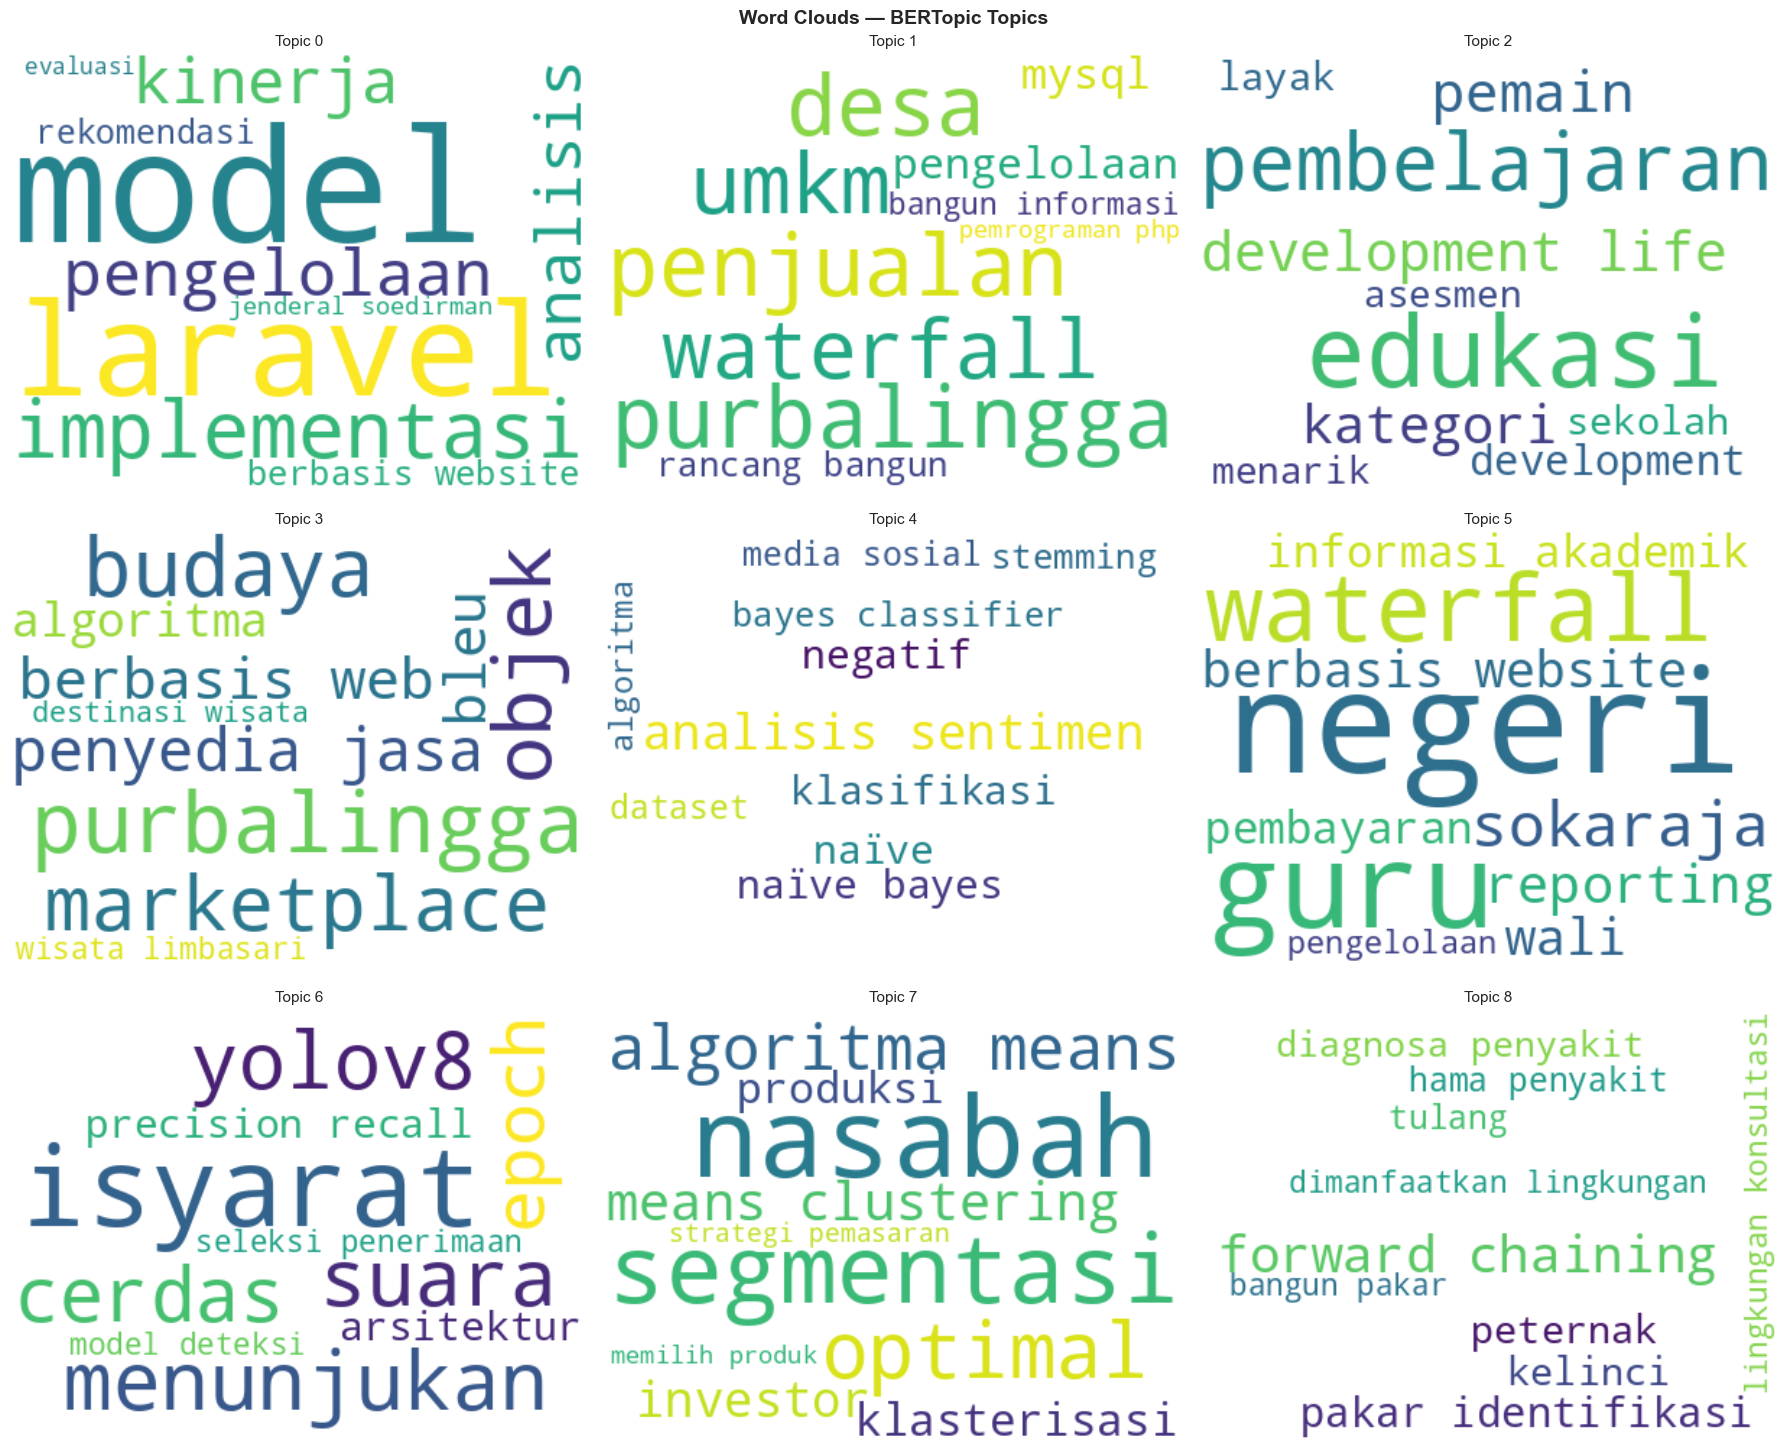

💾 Word clouds disimpan ke: step10_wordclouds_bertopic.png


In [43]:
# ============================================
# 10.1 Word Cloud per Topik (BERTopic)
# ============================================

if DATA_READY:
    from wordcloud import WordCloud
    
    # Ambil topik-topik (exclude outlier -1)
    all_topic_ids = [tid for tid in final_bt_model.get_topics() if tid != -1]
    n_topics_to_show = min(len(all_topic_ids), 9)  # max 9 untuk grid 3x3
    top_topic_ids = all_topic_ids[:n_topics_to_show]
    
    cols = 3
    rows = (n_topics_to_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    fig.suptitle("Word Clouds — BERTopic Topics", fontsize=14, fontweight="bold")
    
    if rows == 1:
        axes = [axes]
    
    for i, tid in enumerate(top_topic_ids):
        row_idx = i // cols
        col_idx = i % cols
        ax = axes[row_idx][col_idx] if rows > 1 else axes[0][col_idx]
        
        words_scores = final_bt_model.get_topic(tid)
        word_freq = {w: abs(s) for w, s in words_scores if w.strip()}
        
        if word_freq:
            wc = WordCloud(
                width=400, height=300,
                background_color="white",
                colormap="viridis",
                max_words=30,
            ).generate_from_frequencies(word_freq)
            ax.imshow(wc, interpolation="bilinear")
        
        ax.set_title(f"Topic {tid}", fontsize=11)
        ax.axis("off")
    
    # Hide empty subplots
    for i in range(n_topics_to_show, rows * cols):
        row_idx = i // cols
        col_idx = i % cols
        ax = axes[row_idx][col_idx] if rows > 1 else axes[0][col_idx]
        ax.axis("off")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step10_wordclouds_bertopic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Word clouds disimpan ke: step10_wordclouds_bertopic.png")
else:
    print("⏭️ Langkah ini dilewati.")

In [ ]:
# ============================================
# 10.2 Topic Distribution per Tahun (Heatmap)
# ============================================

if DATA_READY and "year" in df_processed.columns:
    # Buat distribusi topik per tahun dari BERTopic
    df_topic_year = pd.DataFrame({
        "year": df_processed["year"].values,
        "topic": bt_topics,
    })
    
    # Exclude outliers
    df_topic_year = df_topic_year[df_topic_year["topic"] != -1]
    
    # Cross-tabulation
    cross_tab = pd.crosstab(df_topic_year["topic"], df_topic_year["year"], normalize="columns")
    
    # Simpan
    cross_tab.to_csv(OUTPUT_CSV_DIR / "step10_topic_year_distribution.csv")
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(14, max(8, len(cross_tab) * 0.5)))
    sns.heatmap(
        cross_tab, annot=True, fmt=".2f", cmap="YlOrRd",
        linewidths=0.5, ax=ax
    )
    ax.set_title("Distribusi Topik per Tahun (BERTopic) — Proporsi", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Topic ID")
    
    plt.tight_layout()
    fig.savefig(OUTPUT_PLOT_DIR / "step10_topic_year_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Heatmap disimpan ke: step10_topic_year_heatmap.png")
    print("💾 Data disimpan ke: step10_topic_year_distribution.csv")
else:
    print("⏭️ Langkah ini dilewati.")

---
## 11. 💾 Simpan Model & Ringkasan Akhir

In [ ]:
# ============================================
# 11.1 Simpan Model BERTopic
# ============================================

if DATA_READY:
    bt_model_path = OUTPUT_MODEL_DIR / "bertopic_best_model"
    bt_model_path.mkdir(parents=True, exist_ok=True)
    
    # Simpan model (tanpa embedding model untuk hemat ruang)
    final_bt_model.save(
        str(bt_model_path / "model"),
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=False,
    )
    
    # Simpan embeddings
    np.save(str(bt_model_path / "embeddings.npy"), embeddings)
    
    # Simpan metadata
    bt_metadata = {
        "model_type": "bertopic",
        "embedding_model": CONFIG["embedding_model"],
        "best_params": {
            "umap_n_neighbors": int(best_bt["umap_n_neighbors"]),
            "umap_n_components": int(best_bt["umap_n_components"]),
            "umap_min_dist": float(best_bt["umap_min_dist"]),
            "hdbscan_min_cluster_size": int(best_bt["hdbscan_min_cluster_size"]),
            "min_topic_size": int(best_bt["min_topic_size"]),
        },
        "metrics": {
            "coherence_cv": bt_final_coherence,
            "topic_diversity": bt_final_diversity,
            "num_topics": bt_num_topics,
        },
        "saved_at": datetime.now().isoformat(),
    }
    with open(bt_model_path / "metadata.json", "w") as f:
        json.dump(bt_metadata, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Model BERTopic disimpan ke: {bt_model_path}")
    
    # Simpan LDA model
    lda_model_path = OUTPUT_MODEL_DIR / "lda_best_model"
    lda_model_path.mkdir(parents=True, exist_ok=True)
    
    final_lda_model.save(str(lda_model_path / "lda_model"))
    final_lda_dict.save(str(lda_model_path / "dictionary.dict"))
    
    lda_metadata = {
        "model_type": "lda",
        "best_params": {
            "num_topics": int(best_lda["num_topics"]),
            "passes": int(best_lda["passes"]),
            "alpha": best_lda["alpha"],
            "eta": best_lda["eta"],
        },
        "metrics": {
            "coherence_cv": lda_final_coherence,
            "topic_diversity": lda_final_diversity,
            "num_topics": int(best_lda["num_topics"]),
        },
        "saved_at": datetime.now().isoformat(),
    }
    with open(lda_model_path / "metadata.json", "w") as f:
        json.dump(lda_metadata, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Model LDA disimpan ke: {lda_model_path}")
else:
    print("⏭️ Langkah ini dilewati.")

In [ ]:
# ============================================
# 11.2 Ringkasan Semua File Output
# ============================================

# Kumpulkan semua CSV yang dihasilkan
csv_files = sorted(OUTPUT_CSV_DIR.glob("*.csv"))
plot_files = sorted(OUTPUT_PLOT_DIR.glob("*.png"))

summary_records = []

for f in csv_files:
    try:
        df_temp = pd.read_csv(f)
        n_rows = len(df_temp)
        n_cols = len(df_temp.columns)
    except Exception:
        n_rows, n_cols = "?", "?"
    
    summary_records.append({
        "Tipe": "CSV",
        "Nama File": f.name,
        "Rows": n_rows,
        "Cols": n_cols,
        "Path": str(f),
    })

for f in plot_files:
    size_kb = f.stat().st_size / 1024
    summary_records.append({
        "Tipe": "Plot",
        "Nama File": f.name,
        "Rows": f"{size_kb:.0f} KB",
        "Cols": "-",
        "Path": str(f),
    })

df_summary = pd.DataFrame(summary_records)
df_summary.to_csv(OUTPUT_CSV_DIR / "step11_analysis_summary.csv", index=False)

print("="*70)
print("📋 RINGKASAN SEMUA FILE OUTPUT")
print("="*70)
display(df_summary)
print(f"\n💾 Summary disimpan ke: step11_analysis_summary.csv")
print(f"\n📁 Total file CSV  : {len(csv_files)}")
print(f"📁 Total file Plot : {len(plot_files)}")

In [ ]:
# ============================================
# 11.3 Tabel Final untuk Skripsi
# ============================================

if DATA_READY:
    print("="*70)
    print("📝 TABEL-TABEL UNTUK BAB HASIL DAN PEMBAHASAN SKRIPSI")
    print("="*70)
    
    # Tabel 1: Statistik Dataset
    print("\n📌 Tabel 1: Statistik Dataset")
    display(pd.read_csv(OUTPUT_CSV_DIR / "step2_dataset_statistics.csv"))
    
    # Tabel 2: Preprocessing
    print("\n📌 Tabel 2: Hasil Preprocessing")
    display(pd.read_csv(OUTPUT_CSV_DIR / "step3_preprocessing_statistics.csv"))
    
    # Tabel 3: BERTopic Top-5 Tuning
    print("\n📌 Tabel 3: Top-5 Hyperparameter BERTopic")
    display(df_bt_sorted.head(5)[
        ["run_id", "umap_n_neighbors", "umap_n_components", "umap_min_dist",
         "hdbscan_min_cluster_size", "min_topic_size",
         "num_topics", "coherence_cv", "topic_diversity"]
    ])
    
    # Tabel 4: LDA Top-5 Tuning
    print("\n📌 Tabel 4: Top-5 Hyperparameter LDA")
    display(df_lda_sorted.head(5)[
        ["run_id", "num_topics", "passes", "alpha", "eta",
         "coherence_cv", "topic_diversity"]
    ])
    
    # Tabel 5: Perbandingan Final
    print("\n📌 Tabel 5: Perbandingan BERTopic vs LDA")
    display(pd.read_csv(OUTPUT_CSV_DIR / "step8_model_comparison.csv"))
    
    # Tabel 6: Tren Topik
    if (OUTPUT_CSV_DIR / "step9_topic_trends.csv").exists():
        print("\n📌 Tabel 6: Analisis Tren Topik (DTA)")
        display(pd.read_csv(OUTPUT_CSV_DIR / "step9_topic_trends.csv"))
    
    print("\n✅ Semua tabel siap untuk disalin ke dokumen skripsi!")
    print("   File CSV bisa di-import ke Excel/Google Sheets untuk formatting.")
else:
    print("⏭️ Data belum tersedia. Jalankan scraping terlebih dahulu.")

---
## ✅ Selesai!

### Langkah Selanjutnya:
1. **Jika data belum di-scrape**: Jalankan scraping via FastAPI endpoint `/api/v1/scrape` atau siapkan CSV manual dengan kolom: `title`, `abstract`, `year`, `author`, `url`
2. **Letakkan CSV** di `fastapi/data/raw/raw_data.csv`
3. **Jalankan ulang notebook** dari awal
4. **Salin tabel dan plot** dari folder `analysis/output/` ke dokumen skripsi

### Struktur Output:
```
analysis/output/
├── csv/
│   ├── step1_hyperparameter_grid_config.csv
│   ├── step2_dataset_statistics.csv
│   ├── step2_distribusi_per_tahun.csv
│   ├── step3_preprocessing_statistics.csv
│   ├── step3_processed_data.csv
│   ├── step4_embedding_info.csv
│   ├── step5_bertopic_tuning_results.csv
│   ├── step6_lda_tuning_results.csv
│   ├── step7_bertopic_final_topic_info.csv
│   ├── step7_lda_final_topic_info.csv
│   ├── step8_model_comparison.csv
│   ├── step9_topics_over_time.csv
│   ├── step9_topic_trends.csv
│   ├── step10_topic_year_distribution.csv
│   └── step11_analysis_summary.csv
├── plots/
│   ├── step2_eda_overview.png
│   ├── step3_preprocessing_comparison.png
│   ├── step5_bertopic_tuning_results.png
│   ├── step6_lda_tuning_results.png
│   ├── step8_model_comparison.png
│   ├── step9_dynamic_topic_analysis.png
│   ├── step10_wordclouds_bertopic.png
│   └── step10_topic_year_heatmap.png
└── models/
    ├── embeddings_indosbert_large.npy
    ├── bertopic_best_model/
    └── lda_best_model/
```